# Análisis exploratorio de datos — Valoración de mercado de jugadores (Top-5 ligas europeas)

**Objetivo del proyecto:** construir, más adelante, un modelo que prediga el **valor de mercado en euros** (`valor_eur`) de un futbolista a partir de su rendimiento deportivo.

**Fuentes de datos cruzadas:**
- **FBref**: estadísticas de rendimiento por temporada (minutos, goles, asistencias, tiros, tarjetas, métricas por 90 minutos, etc.).
- **Transfermarkt**: valor de mercado, posición detallada, altura y fecha de nacimiento.

**Cobertura:** 5 grandes ligas europeas (Premier League, La Liga, Serie A, Bundesliga, Ligue 1) y 5 temporadas (2021‑2022 a 2025‑2026). Cada fila es una combinación **jugador‑temporada** (y, si hubo traspaso a mitad de temporada, jugador‑temporada‑club).

El dataset (`fbref_tm_dataset.parquet`) **no ha recibido ningún tratamiento previo**: en este notebook se realiza el EDA completo — calidad de datos, valores faltantes, atípicos (univariantes y multivariantes), normalización y visualización — dejando además un dataset tratado listo para la etapa de modelado.

## Índice
1. Carga y primer vistazo
2. Calidad de datos: tipos, duplicados y consistencia
3. Análisis de valores faltantes (diagnóstico y tratamiento)
4. Análisis univariado
5. Detección de atípicos univariante (IQR, Z-score, Z-score modificado/MAD)
6. Detección de atípicos multivariante (Isolation Forest, LOF, Elliptic Envelope, Mahalanobis)
7. Tratamiento de atípicos y transformaciones
8. Normalización / escalado
9. Relación de las variables con el objetivo (bivariante)
10. Visualizaciones avanzadas / no triviales (Plotly, redes, mapas, PCA)
11. Ranking final y guardado del dataset tratado
12. Conclusiones

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import sys
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

import networkx as nx
import missingno as msno

from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.decomposition import PCA

ROOT = Path.cwd().parent
sys.path.append(str(ROOT))
from src.utils import normalizar

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10
pio.templates.default = 'plotly_white'

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)

RANDOM_STATE = 42
DATA_PATH = Path('../data/interim/fbref_tm_dataset.parquet')
OUT_DIR = Path('../data/processed')
OUT_DIR.mkdir(parents=True, exist_ok=True)

LIGA_COLOR = {'Premier League': '#3b6ea5', 'La Liga': '#c0504d', 'Serie A': '#4bacc6',
              'Bundesliga': '#8064a2', 'Ligue 1': '#9bbb59'}

## 1. Carga y primer vistazo

In [2]:
df_raw = pd.read_parquet(DATA_PATH)
print(f"Filas: {df_raw.shape[0]:,}  |  Columnas: {df_raw.shape[1]}")
df_raw.head()

Filas: 13,953  |  Columnas: 69


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,Playing Time_MP,Playing Time_Starts,Playing Time_Min,Playing Time_90s,Performance_Gls,Performance_Ast,Performance_G+A,Performance_G-PK,Performance_PK,Performance_PKatt,Performance_CrdY,Performance_CrdR,Per 90 Minutes_Gls,Per 90 Minutes_Ast,Per 90 Minutes_G+A,Per 90 Minutes_G-PK,Per 90 Minutes_G+A-PK,90s,Standard_Gls,Standard_Sh,Standard_SoT,Standard_SoT%,Standard_Sh/90,Standard_SoT/90,Standard_G/Sh,Standard_G/SoT,Standard_PK,Standard_PKatt,Performance_2CrdY,Performance_Fls,Performance_Fld,Performance_Off,Performance_Crs,Performance_Int,Performance_TklW,Performance_OG,Playing Time_Mn/MP,Playing Time_Min%,Starts_Starts,Starts_Mn/Start,Starts_Compl,Subs_Subs,Subs_Mn/Sub,Subs_unSub,Team Success_PPM,Team Success_onG,Team Success_onGA,Team Success_+/-,Team Success_+/-90,Team Success_On-Off,Season,nom,saison_id,player_id,anio_nac,pid_fb,valor_eur,posicion_tm,altura_m,nacimiento,club
0,1,Max Aarons,ENG,DF,Norwich City,Premier League,21.0,2000.0,34,32,2881,32.0,0,2,2,0,0,0,8,0,0.00,0.06,0.06,0.00,0.06,32.0,0,13,2,15.4,0.41,0.06,0.00,0.00,0,0,0,26,52,1,50,26,45,1,85,84.2,32,89.0,29,2,22.0,2,0.53,18,69,-51,-1.59,0.08,2021-2022,max aarons,2021,471690,2000.0,471690,22000000.0,Right-Back,1.77,04/01/2000,Norwich City
1,2,Yunis Abdelhamid,MAR,DF,Reims,Ligue 1,33.0,1987.0,34,34,2983,33.1,2,0,2,2,0,0,5,1,0.06,0.00,0.06,0.06,0.06,33.1,2,18,6,33.3,0.54,0.18,0.11,0.33,0,0,0,38,25,0,4,67,28,0,88,87.2,34,88.0,33,0,NaN,0,1.12,38,41,-3,-0.09,-0.50,2021-2022,yunis abdelhamid,2021,199704,1987.0,199704,1200000.0,Centre-Back,1.90,28/09/1987,Stade Reims
2,3,Salis Abdul Samed,GHA,MF,Clermont Foot,Ligue 1,21.0,2000.0,31,29,2462,27.4,1,0,1,1,0,0,12,3,0.04,0.00,0.04,0.04,0.04,27.4,1,18,5,27.8,0.66,0.18,0.06,0.20,0,0,2,43,37,0,14,40,26,0,79,72.0,29,82.0,19,2,38.0,1,1.10,26,43,-17,-0.62,0.69,2021-2022,salis abdul samed,2021,688707,2000.0,688707,3000000.0,Defensive Midfield,1.79,26/03/2000,Clermont Foot 63
3,4,Laurent Abergel,FRA,MF,Lorient,Ligue 1,28.0,1993.0,34,34,2956,32.8,0,2,2,0,0,0,9,0,0.00,0.06,0.06,0.00,0.06,32.8,0,30,7,23.3,0.91,0.21,0.00,0.00,0,0,0,41,69,1,37,54,63,0,87,86.4,34,87.0,26,0,NaN,0,0.82,27,59,-32,-0.97,-1.75,2021-2022,laurent abergel,2021,238626,1993.0,238626,3000000.0,Defensive Midfield,1.70,01/02/1993,FC Lorient
4,5,Charles Abi,FRA,FW,Saint-Étienne,Ligue 1,21.0,2000.0,1,1,45,0.5,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.5,0,0,0,NaN,0.00,0.00,NaN,NaN,0,0,0,1,0,0,1,0,0,0,45,1.3,1,45.0,0,0,NaN,0,1.00,0,0,0,0.00,0.93,2021-2022,charles abi,2021,418658,2000.0,418658,1500000.0,Centre-Forward,1.89,12/04/2000,AS Saint-Étienne


In [3]:
print('Tipos de dato por columna:')
print(df_raw.dtypes.value_counts())
print()
print(f"Jugadores únicos (player_id): {df_raw['player_id'].nunique():,}")
print(f"Temporadas: {sorted(df_raw['Season'].unique())}")
print(f"Ligas: {sorted(df_raw['Comp'].unique())}")

Tipos de dato por columna:
int64      33
float64    22
str        14
Name: count, dtype: int64

Jugadores únicos (player_id): 5,481
Temporadas: ['2021-2022', '2022-2023', '2023-2024', '2024-2025', '2025-2026']
Ligas: ['Bundesliga', 'La Liga', 'Ligue 1', 'Premier League', 'Serie A']


## 2. Calidad de datos: tipos, duplicados y consistencia

In [4]:
df = df_raw.copy()

# 'Per 90 Minutes_G-PK' quedó como texto (artefacto del scraping) -> a float
df['Per 90 Minutes_G-PK'] = pd.to_numeric(df['Per 90 Minutes_G-PK'], errors='coerce')

# Fecha de nacimiento (Transfermarkt) a datetime
df['nacimiento'] = pd.to_datetime(df['nacimiento'], format='%d/%m/%Y', errors='coerce')

# Columnas categóricas de baja cardinalidad
cat_cols = ['Nation', 'Pos', 'Squad', 'Comp', 'Season', 'posicion_tm', 'club']
for c in cat_cols:
    df[c] = df[c].astype('category')

print("dtype 'Per 90 Minutes_G-PK':", df['Per 90 Minutes_G-PK'].dtype)
print("dtype 'nacimiento':", df['nacimiento'].dtype)
df[cat_cols].dtypes

dtype 'Per 90 Minutes_G-PK': float64
dtype 'nacimiento': datetime64[us]


Nation         category
Pos            category
Squad          category
Comp           category
Season         category
posicion_tm    category
club           category
dtype: object

In [5]:
print('Filas totalmente duplicadas:', df.duplicated().sum())

dup_ps = df[df.duplicated(subset=['player_id', 'Season'], keep=False)].sort_values(['player_id', 'Season'])
print(f"Filas que comparten jugador+temporada (fichajes a mitad de temporada): "
      f"{len(dup_ps)} filas -> {dup_ps['player_id'].nunique()} jugadores distintos")
dup_ps[['Player', 'Squad', 'Season', 'Playing Time_Min', 'valor_eur']].head(8)

Filas totalmente duplicadas: 0
Filas que comparten jugador+temporada (fichajes a mitad de temporada): 1473 filas -> 639 jugadores distintos


,Player,Squad,Season,Playing Time_Min,valor_eur
13496,Alejo Sarco,Gladbach,2025-2026,53,2000000.0
13497,Alejo Sarco,Leverkusen,2025-2026,74,2000000.0
6841,Jérémy Jacquet,Rennes,2023-2024,5,500000.0
6842,Jérémy Jacquet,Clermont Foot,2023-2024,253,500000.0
12198,Giovane,Hellas Verona,2025-2026,1533,12000000.0
12199,Giovane,Napoli,2025-2026,338,12000000.0
11677,Jaydee Canvot,Toulouse,2025-2026,180,28000000.0
11678,Jaydee Canvot,Crystal Palace,2025-2026,1336,28000000.0


**No son duplicados por error**: cuando un jugador cambia de club a mitad de temporada, FBref reporta una fila de estadísticas por cada club, pero el valor de mercado (`valor_eur`) es el mismo en ambas filas (es un valor puntual, no por club). Esto es importante para el modelado: si se hace un split train/test aleatorio por fila, el mismo jugador y el mismo valor objetivo podrían aparecer en ambos conjuntos → riesgo de **fuga de información**. Se recomienda dividir por `player_id`.

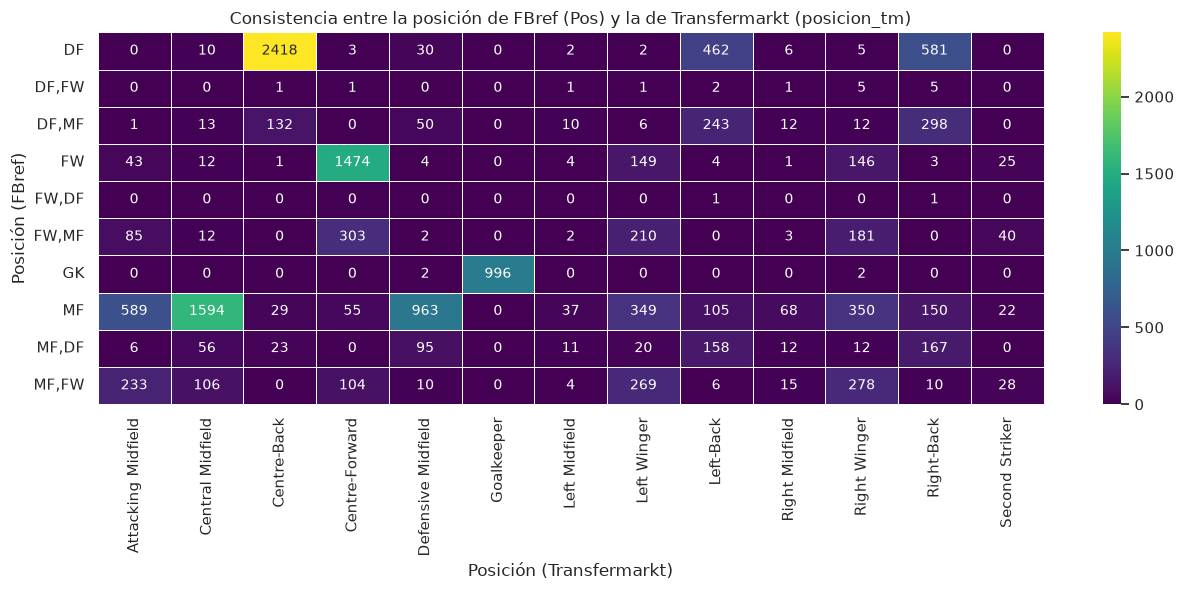

In [6]:
ct = pd.crosstab(df['Pos'], df['posicion_tm'])
fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(ct, annot=True, fmt='d', cmap='viridis', linewidths=.5, ax=ax)
ax.set_title('Consistencia entre la posición de FBref (Pos) y la de Transfermarkt (posicion_tm)')
ax.set_xlabel('Posición (Transfermarkt)')
ax.set_ylabel('Posición (FBref)')
plt.tight_layout()
plt.show()

La correspondencia es coherente: las filas `DF` concentran su masa en `Centre-Back`/`*-Back`, `FW` en `Centre-Forward`/`Winger`, `MF` en las columnas de mediocampo, y `GK` es una categoría limpia 1 a 1. Las combinaciones (`DF,MF`, `MF,FW`, …) de FBref se reparten de forma razonable entre las posiciones más granulares de Transfermarkt. Esto valida que el cruce entre ambas fuentes es correcto y que `posicion_tm` es la variable de posición más informativa para el modelo.

In [7]:
def coincide(squad, club):
    s, c = normalizar(squad), normalizar(club)
    return (s in c) or (c in s)

df['club_coincide'] = [coincide(s, c) for s, c in zip(df['Squad'].astype(str), df['club'].astype(str))]

tasa = df.groupby('Season', observed=True)['club_coincide'].mean().mul(100).round(1)
print('% de filas donde el club de Transfermarkt coincide con el Squad de FBref, por temporada:')
print(tasa)
print(f"\nEn total, {(~df['club_coincide']).sum()} filas ({(~df['club_coincide']).mean()*100:.1f}%) "
      f"muestran un club de Transfermarkt distinto al Squad de esa temporada.")

df.loc[df['Player'] == 'Tammy Abraham', ['Player', 'Squad', 'Season', 'club', 'valor_eur']]

% de filas donde el club de Transfermarkt coincide con el Squad de FBref, por temporada:
Season
2021-2022    88.1
2022-2023    86.7
2023-2024    87.1
2024-2025    86.6
2025-2026    86.5
Name: club_coincide, dtype: float64

En total, 1814 filas (13.0%) muestran un club de Transfermarkt distinto al Squad de esa temporada.


,Player,Squad,Season,club,valor_eur
7,Tammy Abraham,Roma,2021-2022,Chelsea FC,50000000.0
2862,Tammy Abraham,Roma,2022-2023,AS Roma,40000000.0
5673,Tammy Abraham,Roma,2023-2024,AS Roma,30000000.0
8459,Tammy Abraham,Roma,2024-2025,AS Roma,15000000.0
8460,Tammy Abraham,Milan,2024-2025,AS Roma,15000000.0
11252,Tammy Abraham,Aston Villa,2025-2026,Aston Villa,18000000.0


**Hallazgo de calidad de datos:** la columna `club` de Transfermarkt no es un histórico por temporada, sino una instantánea (el club en el momento del scraping o de la valoración más cercana), mientras que `Squad` sí es específico de cada temporada de FBref. Esto explica casos como Tammy Abraham, cuyo `club` aparece como "Chelsea FC" en la fila de la temporada 2021‑2022 aunque ya jugaba en la Roma. La tasa de coincidencia es lógicamente más alta en las temporadas recientes y baja en las más antiguas. **Implicación para el modelado:** para temporadas antiguas, `valor_eur` puede no reflejar exactamente el valor del jugador en *esa* temporada sino uno más cercano al presente, lo que introduce ruido en la variable objetivo para los años más alejados del scraping.

## 3. Análisis de valores faltantes

In [8]:
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_pct = (miss / len(df) * 100).round(2)
tabla_na = pd.DataFrame({'n_faltantes': miss, 'pct_faltante': miss_pct})
tabla_na

,n_faltantes,pct_faltante
Standard_G/SoT,4190,30.03
Standard_SoT%,2532,18.15
Standard_G/Sh,2532,18.15
Subs_Mn/Sub,1960,14.05
Starts_Mn/Start,1858,13.32
anio_nac,698,5.00
pid_fb,698,5.00
valor_eur,118,0.85
Team Success_On-Off,98,0.70
altura_m,61,0.44


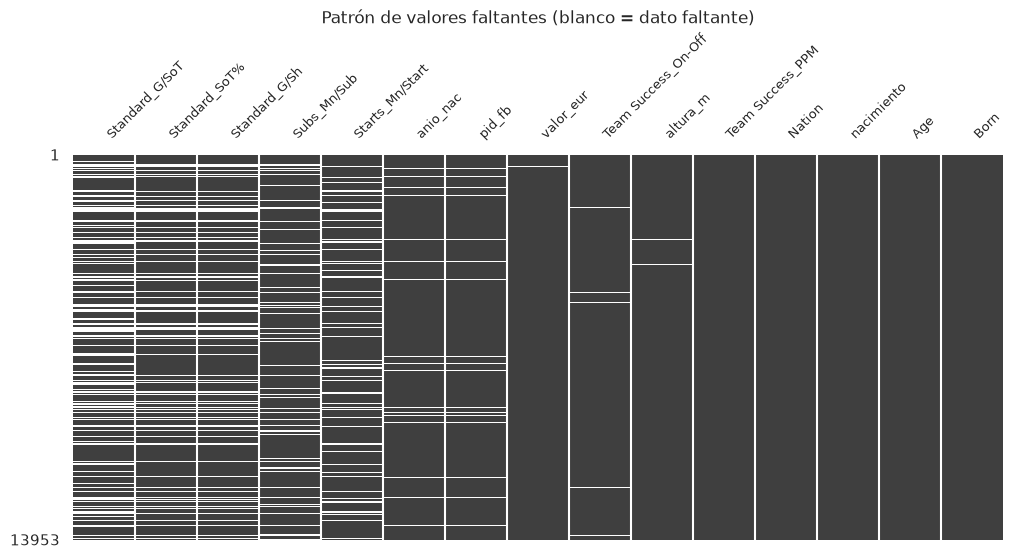

In [9]:
cols_na = miss.index.tolist()
msno.matrix(df[cols_na], figsize=(12, 5), sparkline=False, fontsize=9)
plt.title('Patrón de valores faltantes (blanco = dato faltante)')
plt.show()

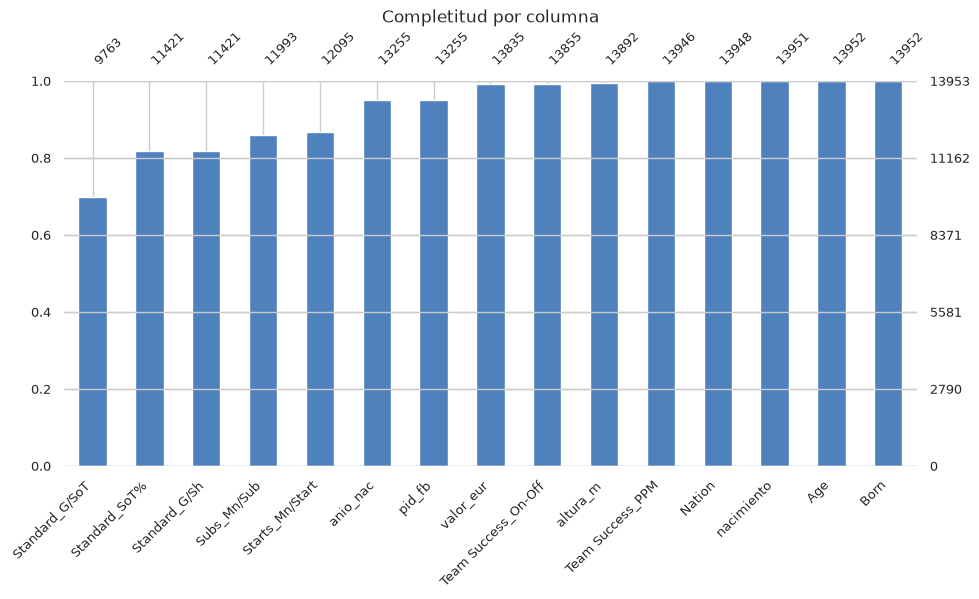

In [10]:
msno.bar(df[cols_na], figsize=(11, 5), fontsize=9, color='#4f81bd')
plt.title('Completitud por columna')
plt.show()

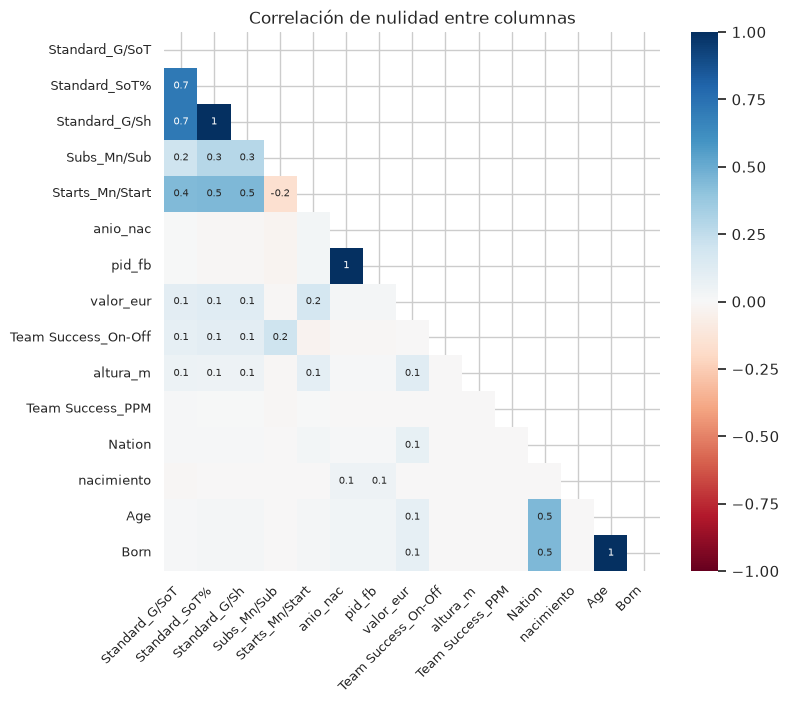

In [11]:
msno.heatmap(df[cols_na], figsize=(8, 7), fontsize=9, cmap='RdBu')
plt.title('Correlación de nulidad entre columnas')
plt.show()

La matriz y el mapa de correlación de nulidad muestran que los faltantes **no son aleatorios**, sino estructurales y agrupados:

| Grupo | Columnas | Causa | Tratamiento |
|---|---|---|---|
| A. Ratios de tiro | `Standard_SoT%`, `Standard_G/Sh`, `Standard_G/SoT` | División entre 0 (jugador con 0 tiros) | Imputar 0 + columna indicadora |
| B. Minutos por aparición | `Starts_Mn/Start`, `Subs_Mn/Sub` | 0 titularidades / 0 suplencias | Imputar 0 + columna indicadora |
| C. Éxito de equipo | `Team Success_PPM`, `Team Success_On-Off` | Pocos casos, sin patrón claro | Mediana por (liga, temporada) |
| D. Demográficos | `Age`, `Born`, `Nation`, `nacimiento` | Muy pocos casos aislados | Imputación puntual / categoría "Desconocida" |
| E. Físico | `altura_m` | No reportado en Transfermarkt | Mediana por posición |
| F. Cruce de IDs | `anio_nac`, `pid_fb` | Jugador no encontrado en el cruce FBref-Transfermarkt | Se deja como NaN + flag de auditoría (no se usa como *feature*) |
| G. Objetivo | `valor_eur` | Jugador sin valoración en Transfermarkt | Se excluye del subconjunto de modelado |

A continuación se trata cada grupo de forma explícita.

In [12]:
# --- Grupo A: ratios de tiro (estructuralmente indefinidos si Sh == 0) ---
df['flag_sin_tiros'] = df['Standard_Sh'].eq(0)
for c in ['Standard_SoT%', 'Standard_G/Sh', 'Standard_G/SoT']:
    df[c] = df[c].fillna(0)
print('Nulos restantes en columnas de ratio de tiro:', df[['Standard_SoT%', 'Standard_G/Sh', 'Standard_G/SoT']].isna().sum().sum())

Nulos restantes en columnas de ratio de tiro: 0


In [13]:
# --- Grupo B: minutos por titularidad / suplencia ---
df['flag_sin_titularidades'] = df['Starts_Starts'].eq(0)
df['Starts_Mn/Start'] = df['Starts_Mn/Start'].fillna(0)

df['flag_sin_suplencias'] = df['Subs_Subs'].eq(0)
df['Subs_Mn/Sub'] = df['Subs_Mn/Sub'].fillna(0)

print('Nulos restantes:', df[['Starts_Mn/Start', 'Subs_Mn/Sub']].isna().sum().sum())

Nulos restantes: 0


In [14]:
# --- Grupo C: métricas de éxito de equipo -> mediana por (liga, temporada) ---
for c in ['Team Success_PPM', 'Team Success_On-Off']:
    df[c] = df.groupby(['Comp', 'Season'], observed=True)[c].transform(lambda s: s.fillna(s.median()))
print('Nulos restantes:', df[['Team Success_PPM', 'Team Success_On-Off']].isna().sum().sum())

Nulos restantes: 0


In [15]:
# --- Grupo D: demográficos ---
mask_age = df['Age'].isna()
season_start_year = df['Season'].astype(str).str[:4].astype(int)
df.loc[mask_age, 'Age'] = season_start_year[mask_age] - df.loc[mask_age, 'nacimiento'].dt.year

df['Nation'] = df['Nation'].cat.add_categories(['Desconocida']).fillna('Desconocida')

print('Nulos restantes en Age:', df['Age'].isna().sum())
print('Nulos restantes en Nation:', df['Nation'].isna().sum())

Nulos restantes en Age: 0
Nulos restantes en Nation: 0


In [16]:
# --- Grupo E: altura -> mediana por posición (Transfermarkt) ---
df['altura_m'] = df.groupby('posicion_tm', observed=True)['altura_m'].transform(lambda s: s.fillna(s.median()))
print('Nulos restantes en altura_m:', df['altura_m'].isna().sum())

Nulos restantes en altura_m: 0


In [17]:
# --- Grupo F: campos de auditoría del cruce FBref-Transfermarkt (no se imputan) ---
df['flag_cruce_verificado'] = df['pid_fb'].notna()
print((df['flag_cruce_verificado'].value_counts(normalize=True) * 100).round(2))

flag_cruce_verificado
True     95.0
False     5.0
Name: proportion, dtype: float64


**Grupo G — objetivo (`valor_eur`) faltante:** no tiene sentido imputar la variable que se busca predecir, ya que introduciría un sesgo circular. En su lugar, se analiza el perfil de estas filas y luego se excluyen del subconjunto usado para el resto del análisis y el futuro modelado.

In [18]:
sin_valor = df[df['valor_eur'].isna()]
print(f"{len(sin_valor)} filas sin valor de mercado ({len(sin_valor) / len(df) * 100:.2f}% del total)")
sin_valor[['Age', 'Playing Time_Min']].describe()

118 filas sin valor de mercado (0.85% del total)


,Age,Playing Time_Min
count,118.000000,118.000000
mean,19.847458,114.822034
std,5.589409,394.778454
min,15.000000,1.000000
25%,17.000000,5.000000
50%,18.000000,14.500000
75%,19.000000,53.250000
max,39.000000,3177.000000


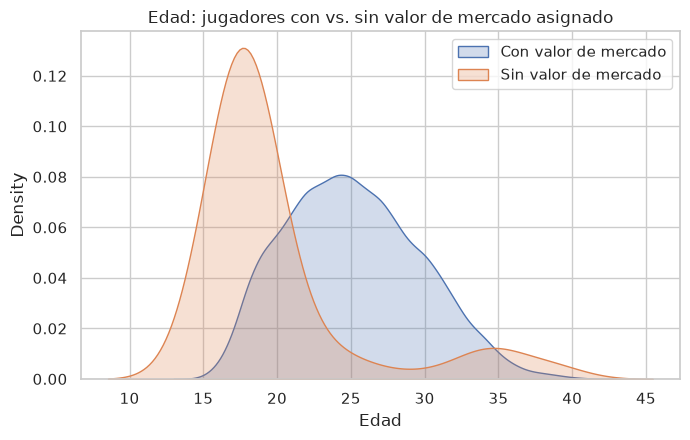

In [19]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.kdeplot(df.loc[df['valor_eur'].notna(), 'Age'], label='Con valor de mercado', fill=True, ax=ax)
sns.kdeplot(sin_valor['Age'], label='Sin valor de mercado', fill=True, ax=ax)
ax.set_title('Edad: jugadores con vs. sin valor de mercado asignado')
ax.set_xlabel('Edad')
ax.legend()
plt.tight_layout()
plt.show()

Los jugadores sin valor de mercado son sistemáticamente **muy jóvenes y con pocos minutos**: son en su mayoría debutantes de academia todavía sin valoración pública en Transfermarkt. Confirma que el faltante en el objetivo no es aleatorio, sino que corresponde a un segmento identificable (y esperable) del mercado.

In [20]:
df_model = df.dropna(subset=['valor_eur']).copy()
print('df        (completo, para EDA general de calidad de datos):', df.shape)
print('df_model  (con objetivo, usado en el resto del análisis):   ', df_model.shape)

restantes = df_model.isna().sum()
restantes = restantes[restantes > 0]
print('\nColumnas con nulos restantes (dejadas a propósito, ver Grupo F y demográficos residuales):')
restantes

df        (completo, para EDA general de calidad de datos): (13953, 74)
df_model  (con objetivo, usado en el resto del análisis):    (13835, 74)

Columnas con nulos restantes (dejadas a propósito, ver Grupo F y demográficos residuales):


anio_nac      686
pid_fb        686
nacimiento      2
dtype: int64

## 4. Análisis univariado

In [21]:
core_num = ['Age', 'altura_m', 'Playing Time_Min', 'Playing Time_MP', 'Performance_Gls',
            'Performance_Ast', 'Standard_Sh', 'Performance_CrdY', 'Performance_CrdR',
            'Team Success_PPM', 'valor_eur']
df_model[core_num].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,13835.0,2.515229e+01,4.560408e+00,15.00,22.00,25.00,28.00,4.100000e+01
altura_m,13835.0,1.829738e+00,6.623945e-02,1.63,1.78,1.83,1.88,2.050000e+00
Playing Time_Min,13835.0,1.238279e+03,9.676467e+02,1.00,331.50,1105.00,2014.50,3.420000e+03
Playing Time_MP,13835.0,1.925602e+01,1.150218e+01,1.00,9.00,20.00,30.00,3.800000e+01
Performance_Gls,13835.0,1.712541e+00,3.153577e+00,0.00,0.00,0.00,2.00,3.600000e+01
Performance_Ast,13835.0,1.200434e+00,1.939880e+00,0.00,0.00,0.00,2.00,2.100000e+01
Standard_Sh,13835.0,1.581091e+01,1.967681e+01,0.00,2.00,9.00,22.00,1.610000e+02
Performance_CrdY,13835.0,2.588724e+00,2.674688e+00,0.00,0.00,2.00,4.00,1.700000e+01
Performance_CrdR,13835.0,1.227322e-01,3.656496e-01,0.00,0.00,0.00,0.00,3.000000e+00
Team Success_PPM,13835.0,1.325852e+00,6.549997e-01,0.00,0.94,1.28,1.73,3.000000e+00


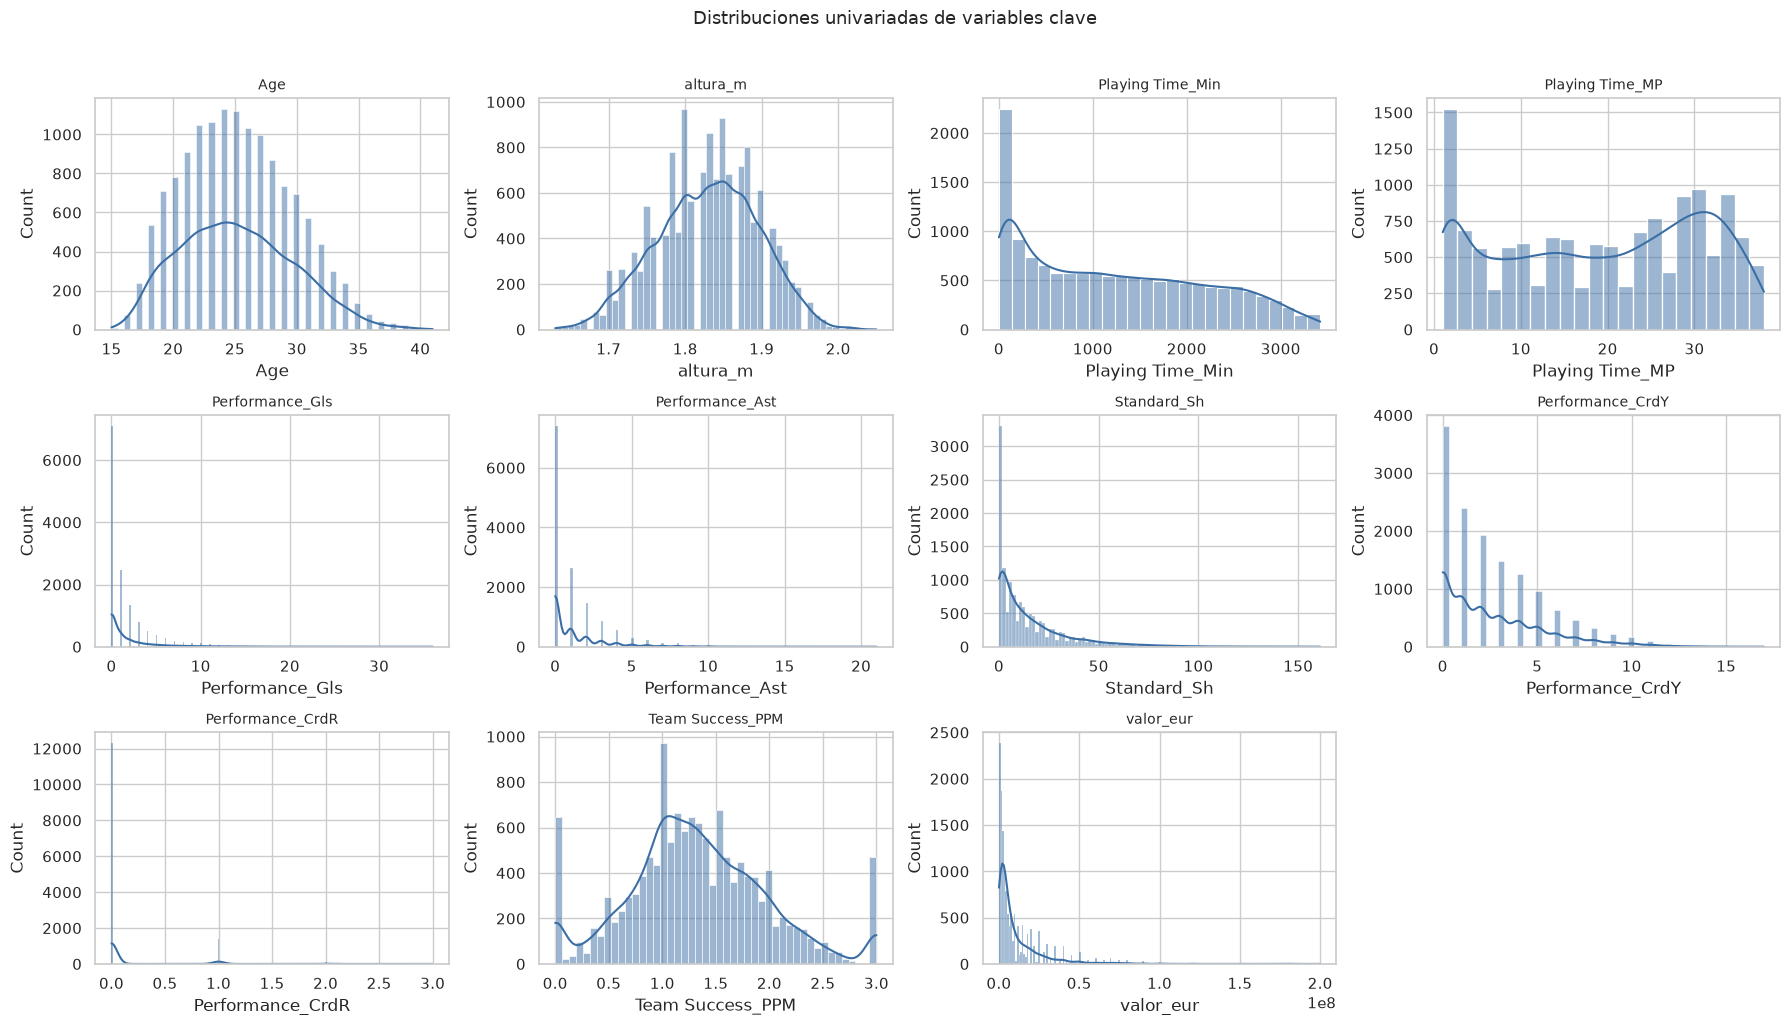

In [22]:
fig, axes = plt.subplots(3, 4, figsize=(18, 10))
for ax, col in zip(axes.flat, core_num):
    sns.histplot(df_model[col], kde=True, ax=ax, color='#3b6ea5')
    ax.set_title(col, fontsize=10)
for ax in axes.flat[len(core_num):]:
    ax.axis('off')
plt.suptitle('Distribuciones univariadas de variables clave', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

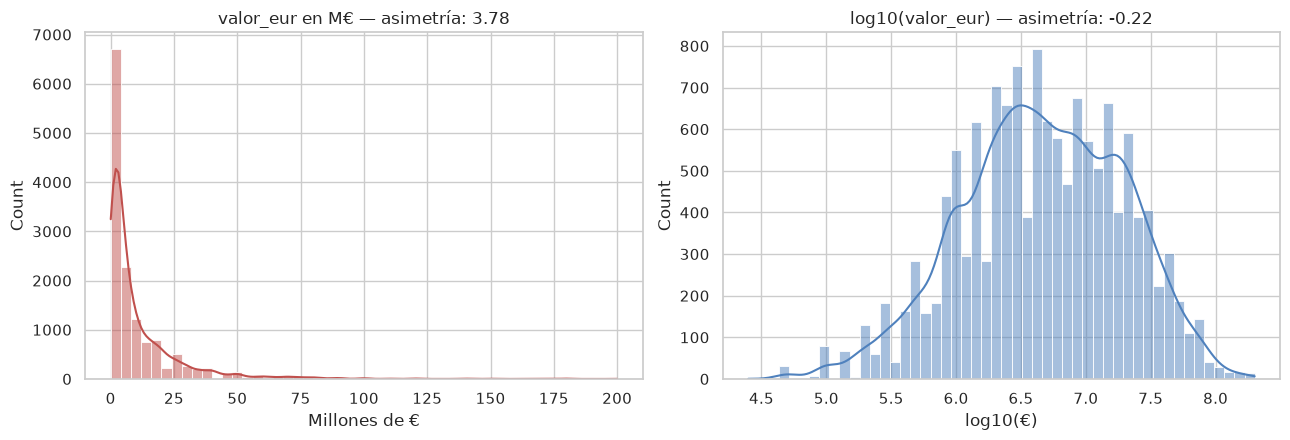

In [23]:
df_model['log_valor_eur'] = np.log10(df_model['valor_eur'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df_model['valor_eur'] / 1e6, bins=50, kde=True, ax=axes[0], color='#c0504d')
axes[0].set_title(f"valor_eur en M€ — asimetría: {stats.skew(df_model['valor_eur']):.2f}")
axes[0].set_xlabel('Millones de €')

sns.histplot(df_model['log_valor_eur'], bins=50, kde=True, ax=axes[1], color='#4f81bd')
axes[1].set_title(f"log10(valor_eur) — asimetría: {stats.skew(df_model['log_valor_eur']):.2f}")
axes[1].set_xlabel('log10(€)')
plt.tight_layout()
plt.show()

`valor_eur` está fuertemente sesgado a la derecha (unos pocos jugadores de élite valen decenas/cientos de millones frente a una mayoría por debajo de los 10M€). El logaritmo en base 10 lo acerca mucho a una distribución simétrica: **se usará `log10(valor_eur)` como variable objetivo de trabajo** en el resto del análisis y, previsiblemente, en el modelado.

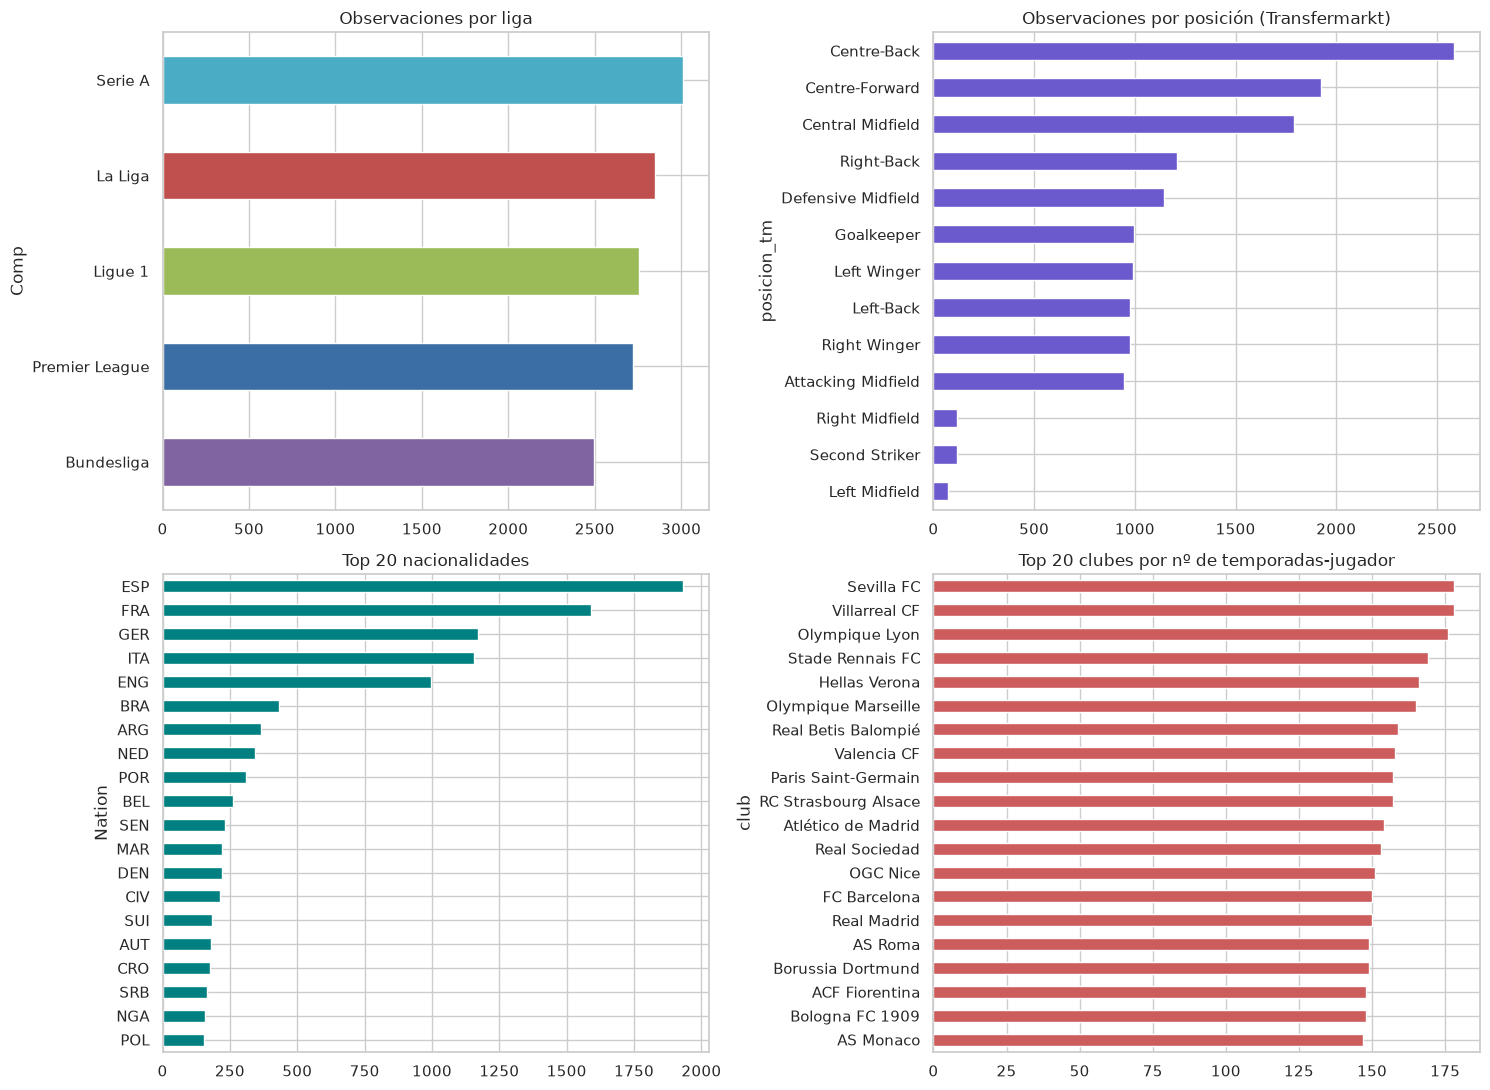

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

df_model['Comp'].value_counts().plot(kind='barh', ax=axes[0, 0], color=[LIGA_COLOR.get(c, 'gray') for c in df_model['Comp'].value_counts().index])
axes[0, 0].set_title('Observaciones por liga')
axes[0, 0].invert_yaxis()

df_model['posicion_tm'].value_counts().plot(kind='barh', ax=axes[0, 1], color='slateblue')
axes[0, 1].set_title('Observaciones por posición (Transfermarkt)')
axes[0, 1].invert_yaxis()

df_model['Nation'].value_counts().head(20).plot(kind='barh', ax=axes[1, 0], color='teal')
axes[1, 0].set_title('Top 20 nacionalidades')
axes[1, 0].invert_yaxis()

df_model['club'].value_counts().head(20).plot(kind='barh', ax=axes[1, 1], color='indianred')
axes[1, 1].set_title('Top 20 clubes por nº de temporadas-jugador')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

## 5. Detección de atípicos univariante

In [25]:
outlier_feats = ['Age', 'altura_m', 'Playing Time_Min', 'Performance_Gls', 'Performance_Ast',
                  'Standard_Sh', 'Performance_CrdY', 'Team Success_PPM', 'valor_eur']

def pct_iqr(s, k=1.5):
    q1, q3 = s.quantile([.25, .75])
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return ((s < lo) | (s > hi)).mean() * 100

def pct_zscore(s, th=3):
    z = (s - s.mean()) / s.std()
    return (z.abs() > th).mean() * 100

def pct_mad(s, th=3.5):
    med = s.median()
    mad = (s - med).abs().median()
    if mad == 0:
        return np.nan
    mz = 0.6745 * (s - med) / mad
    return (mz.abs() > th).mean() * 100

resumen_out = pd.DataFrame({
    'IQR (1.5x)': {c: pct_iqr(df_model[c]) for c in outlier_feats},
    'Z-score (|z|>3)': {c: pct_zscore(df_model[c]) for c in outlier_feats},
    'Z-score modificado (MAD)': {c: pct_mad(df_model[c]) for c in outlier_feats},
}).round(2)
resumen_out

,IQR (1.5x),Z-score (|z|>3),Z-score modificado (MAD)
Age,0.48,0.25,0.03
altura_m,0.07,0.07,0.00
Playing Time_Min,0.00,0.00,0.00
Performance_Gls,8.96,2.15,NaN
Performance_Ast,4.43,1.90,NaN
Standard_Sh,6.04,2.09,6.69
Performance_CrdY,1.25,1.25,0.25
Team Success_PPM,3.41,0.00,0.00
valor_eur,7.86,2.20,10.91


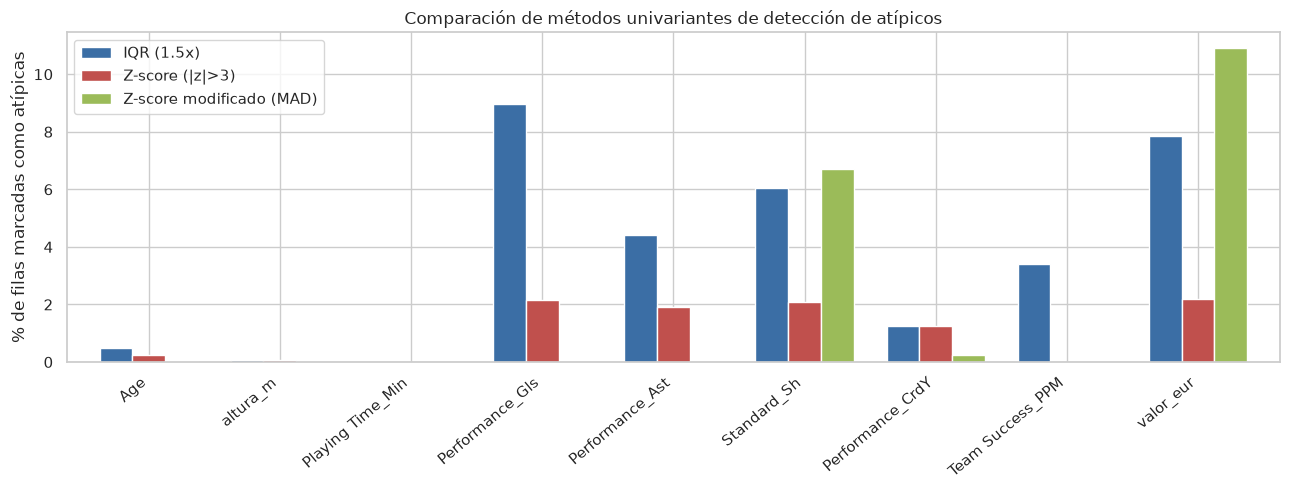

In [26]:
ax = resumen_out.plot(kind='bar', figsize=(13, 5), width=0.75, color=['#3b6ea5', '#c0504d', '#9bbb59'])
ax.set_ylabel('% de filas marcadas como atípicas')
ax.set_title('Comparación de métodos univariantes de detección de atípicos')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

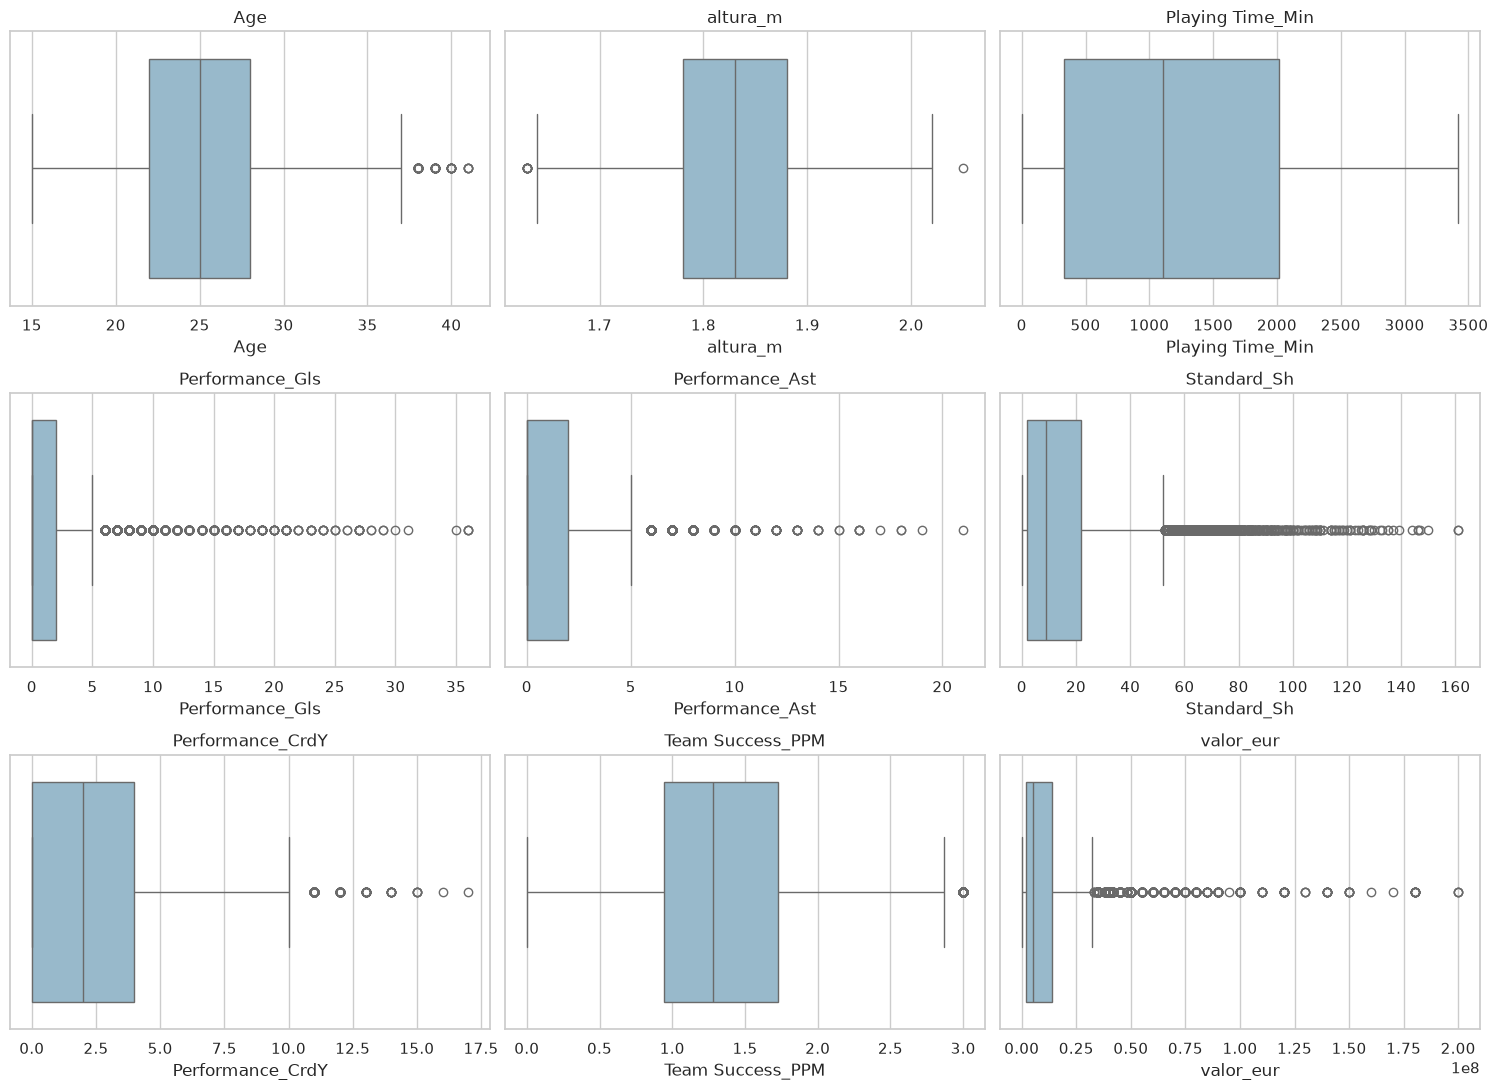

In [27]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.flat, outlier_feats):
    sns.boxplot(x=df_model[col], ax=ax, color='#8fbcd4')
    ax.set_title(col)
plt.tight_layout()
plt.show()

El método IQR es el más "agresivo" en variables de conteo muy asimétricas (`Performance_Gls`, `Standard_Sh`, `valor_eur`), porque su umbral se calcula sobre cuartiles que, en distribuciones sesgadas, quedan muy próximos entre sí. El **Z-score modificado (basado en MAD)** es más robusto ante el sesgo y marca sistemáticamente menos observaciones. Esto ya sugiere que buena parte de lo que el IQR llama "atípico" en `valor_eur` o en goles es simplemente la cola derecha natural del rendimiento/mercado (jugadores estrella), no errores de captura.

## 6. Detección de atípicos multivariante

In [28]:
mv_feats = ['Age', 'altura_m', 'Playing Time_Min', 'Performance_Gls', 'Performance_Ast',
            'Standard_Sh', 'Performance_CrdY', 'Team Success_PPM', 'valor_eur']
X = df_model[mv_feats].copy()
Xs = StandardScaler().fit_transform(X)

iso = IsolationForest(random_state=RANDOM_STATE, contamination=0.02).fit(Xs)
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02)
ee = EllipticEnvelope(contamination=0.02, random_state=RANDOM_STATE).fit(Xs)

flags = pd.DataFrame({
    'IsolationForest': iso.predict(Xs) == -1,
    'LocalOutlierFactor': lof.fit_predict(Xs) == -1,
    'EllipticEnvelope (Mahalanobis robusto)': ee.predict(Xs) == -1,
}, index=df_model.index)

# Distancia de Mahalanobis clásica (covarianza estándar, no robusta)
cov = np.cov(Xs, rowvar=False)
diff = Xs - Xs.mean(axis=0)
maha2 = np.einsum('ij,jk,ik->i', diff, np.linalg.inv(cov), diff)
k = int(len(Xs) * 0.02)
flags['Mahalanobis clásica'] = False
flags.iloc[np.argsort(maha2)[-k:], flags.columns.get_loc('Mahalanobis clásica')] = True

df_model['n_metodos_atipico'] = flags.sum(axis=1).values
print('Nº de observaciones marcadas por cada método:')
flags.sum()

Nº de observaciones marcadas por cada método:


IsolationForest                           277
LocalOutlierFactor                        277
EllipticEnvelope (Mahalanobis robusto)    277
Mahalanobis clásica                       276
dtype: int64

In [29]:
df_model.sort_values('n_metodos_atipico', ascending=False)[
    ['Player', 'Squad', 'Season', 'Age', 'valor_eur', 'n_metodos_atipico']
].head(15)

,Player,Squad,Season,Age,valor_eur,n_metodos_atipico
1728,Lionel Messi,PSG,2021-2022,34.0,50000000.0,4
1474,Robert Lewandowski,Bayern Munich,2021-2022,32.0,45000000.0,4
1820,Thomas Müller,Bayern Munich,2021-2022,31.0,22000000.0,4
10699,Mohamed Salah,Liverpool,2024-2025,32.0,50000000.0,4
4710,Neymar,PSG,2022-2023,30.0,60000000.0,4
6675,Álex Grimaldo,Leverkusen,2023-2024,27.0,45000000.0,4
13134,Michael Olise,Bayern Munich,2025-2026,23.0,150000000.0,4
6924,Harry Kane,Bayern Munich,2023-2024,30.0,100000000.0,4
12499,Harry Kane,Bayern Munich,2025-2026,32.0,60000000.0,4
3493,Kevin De Bruyne,Manchester City,2022-2023,31.0,70000000.0,4


Los casos en los que **coinciden los cuatro métodos multivariantes** son, literalmente, algunos de los mejores futbolistas del mundo en esa temporada (Messi, Mbappé, Haaland, Lewandowski, Kane, Neymar, De Bruyne, Lamine Yamal…). Esto confirma la lectura del apartado anterior: **son atípicos reales y valiosos, no errores de datos**. Eliminarlos sería eliminar precisamente la señal que un modelo de valoración necesita aprender para el extremo superior del mercado.

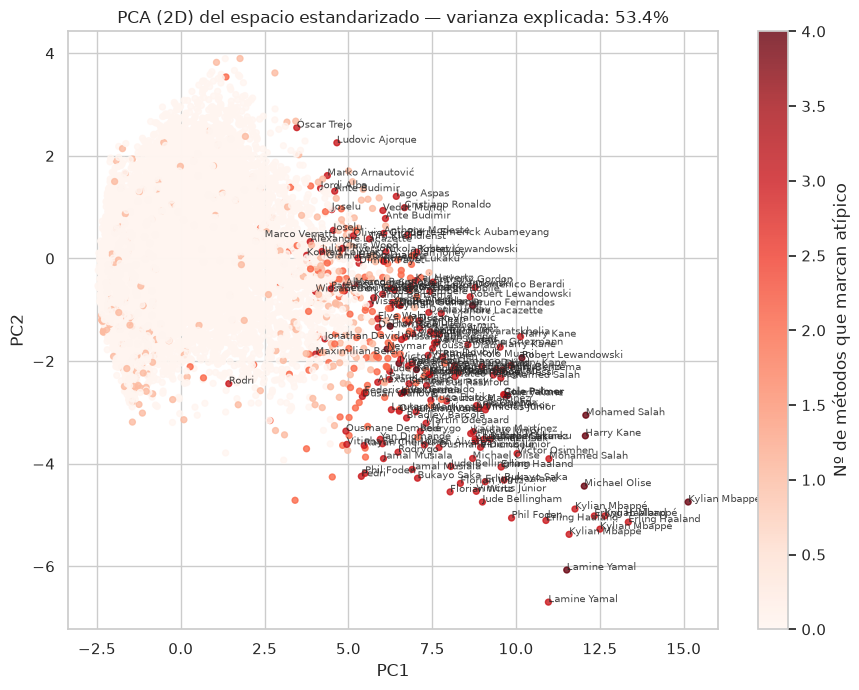

In [30]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(Xs)
df_pca = pd.DataFrame(coords, columns=['PC1', 'PC2'], index=df_model.index)
df_pca['n_metodos_atipico'] = df_model['n_metodos_atipico'].values
df_pca['Player'] = df_model['Player'].values

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['n_metodos_atipico'], cmap='Reds', s=18, alpha=.8)
plt.colorbar(sc, label='Nº de métodos que marcan atípico')
for _, r in df_pca[df_pca['n_metodos_atipico'] >= 3].iterrows():
    ax.annotate(r['Player'], (r['PC1'], r['PC2']), fontsize=7, alpha=.85)
ax.set_title(f"PCA (2D) del espacio estandarizado — varianza explicada: {pca.explained_variance_ratio_.sum()*100:.1f}%")
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

## 7. Tratamiento de atípicos y transformaciones

**Decisión de tratamiento:** dado que los atípicos multivariantes son jugadores de élite genuinos (la señal más relevante para el objetivo del proyecto), **no se eliminan filas**. En su lugar se aplican transformaciones que reducen su influencia desproporcionada sin destruir la información:

1. **Log-transformación** (`log1p`) de variables de conteo muy asimétricas y del objetivo.
2. **Winsorización** (recorte a percentiles 1-99) como alternativa suave para variables de ratio inestables.
3. **Escalado robusto** (sección 8), menos sensible a valores extremos que el escalado estándar.

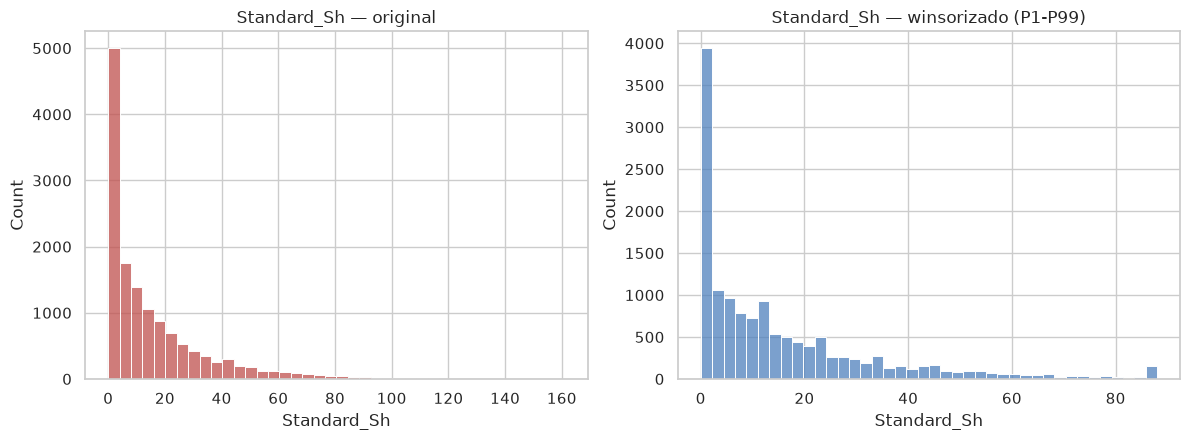

In [31]:
def winsorize(s, lower=0.01, upper=0.99):
    lo, hi = s.quantile([lower, upper])
    return s.clip(lo, hi)

demo_col = 'Standard_Sh'
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df_model[demo_col], bins=40, ax=axes[0], color='#c0504d')
axes[0].set_title(f'{demo_col} — original')
sns.histplot(winsorize(df_model[demo_col]), bins=40, ax=axes[1], color='#4f81bd')
axes[1].set_title(f'{demo_col} — winsorizado (P1-P99)')
plt.tight_layout()
plt.show()

In [32]:
skewed_cols = ['Performance_Gls', 'Performance_Ast', 'Standard_Sh', 'Standard_SoT',
               'Performance_Crs', 'Performance_Fls']
for c in skewed_cols:
    df_model[f'log1p_{c}'] = np.log1p(df_model[c])

print(f"{'Variable':22s} {'Asimetría original':>20s} {'Asimetría log1p':>18s}")
for c in skewed_cols:
    print(f"{c:22s} {stats.skew(df_model[c]):20.2f} {stats.skew(df_model[f'log1p_{c}']):18.2f}")

Variable                 Asimetría original    Asimetría log1p
Performance_Gls                        3.49               1.04
Performance_Ast                        2.56               0.93
Standard_Sh                            2.12              -0.22
Standard_SoT                           2.68               0.33
Performance_Crs                        2.96               0.18
Performance_Fls                        1.07              -0.58


## 8. Normalización / escalado

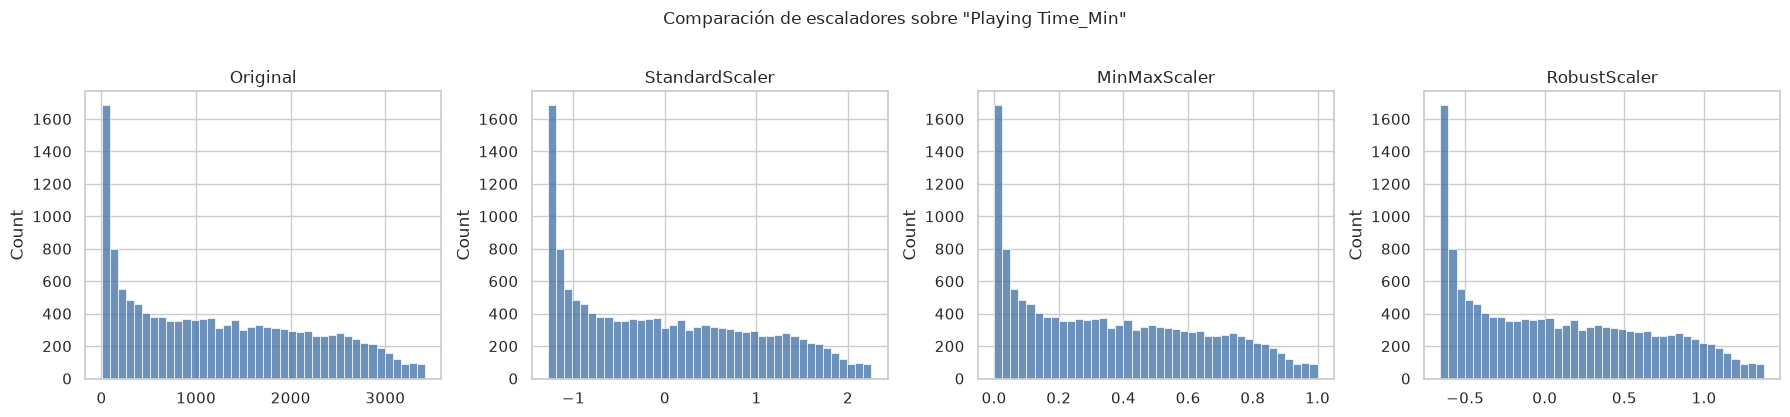

In [33]:
col = 'Playing Time_Min'
vals = df_model[[col]].values
escalados = {
    'Original': vals.flatten(),
    'StandardScaler': StandardScaler().fit_transform(vals).flatten(),
    'MinMaxScaler': MinMaxScaler().fit_transform(vals).flatten(),
    'RobustScaler': RobustScaler().fit_transform(vals).flatten(),
}
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, v) in zip(axes, escalados.items()):
    sns.histplot(v, bins=40, ax=ax, color='#3b6ea5')
    ax.set_title(name)
plt.suptitle(f'Comparación de escaladores sobre "{col}"', y=1.03)
plt.tight_layout()
plt.show()

`RobustScaler` (basado en mediana y rango intercuartílico) es el más adecuado aquí: conserva la forma de la distribución sin dejar que los minutos de los jugadores más utilizados (los "atípicos" que sí queremos conservar) compriman la escala del resto, como sí ocurre con `MinMaxScaler`.

In [34]:
scale_feats = ['Age', 'altura_m', 'Playing Time_Min', 'Performance_Gls', 'Performance_Ast',
               'Standard_Sh', 'Performance_CrdY', 'Team Success_PPM']
rs = RobustScaler()
scaled = rs.fit_transform(df_model[scale_feats])
df_scaled_cols = pd.DataFrame(scaled, columns=[f'{c}_rs' for c in scale_feats], index=df_model.index)
df_model = pd.concat([df_model, df_scaled_cols], axis=1)
df_model[df_scaled_cols.columns].describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
Age_rs,0.025382,0.760068,-1.666667,2.666667
altura_m_rs,-0.002624,0.662394,-2.000000,2.200000
Playing Time_Min_rs,0.079191,0.574953,-0.655971,1.375520
Performance_Gls_rs,0.856270,1.576788,0.000000,18.000000
Performance_Ast_rs,0.600217,0.969940,0.000000,10.500000
Standard_Sh_rs,0.340546,0.983841,-0.450000,7.600000
Performance_CrdY_rs,0.147181,0.668672,-0.500000,3.750000
Team Success_PPM_rs,0.058040,0.829114,-1.620253,2.177215


## 9. Relación de las variables con el objetivo (bivariante)

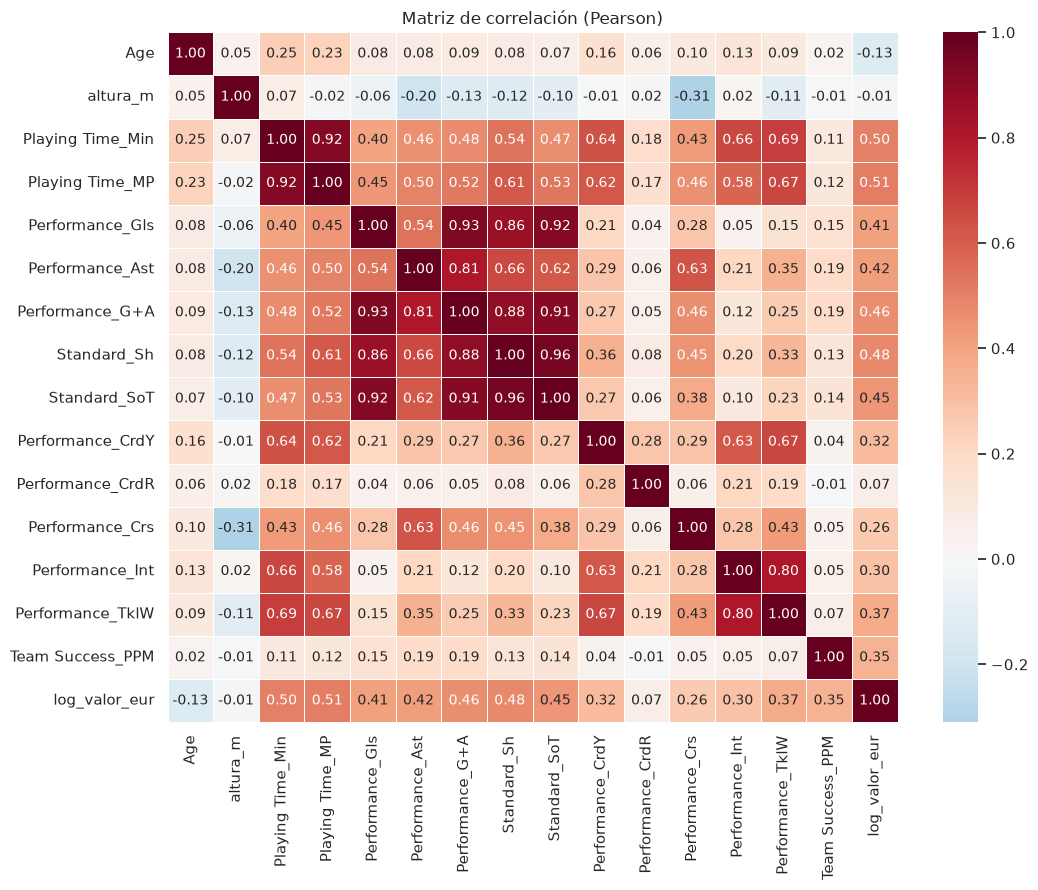

In [35]:
corr_feats = ['Age', 'altura_m', 'Playing Time_Min', 'Playing Time_MP', 'Performance_Gls',
              'Performance_Ast', 'Performance_G+A', 'Standard_Sh', 'Standard_SoT',
              'Performance_CrdY', 'Performance_CrdR', 'Performance_Crs', 'Performance_Int',
              'Performance_TklW', 'Team Success_PPM', 'log_valor_eur']
corr = df_model[corr_feats].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, linewidths=.4)
ax.set_title('Matriz de correlación (Pearson)')
plt.tight_layout()
plt.show()

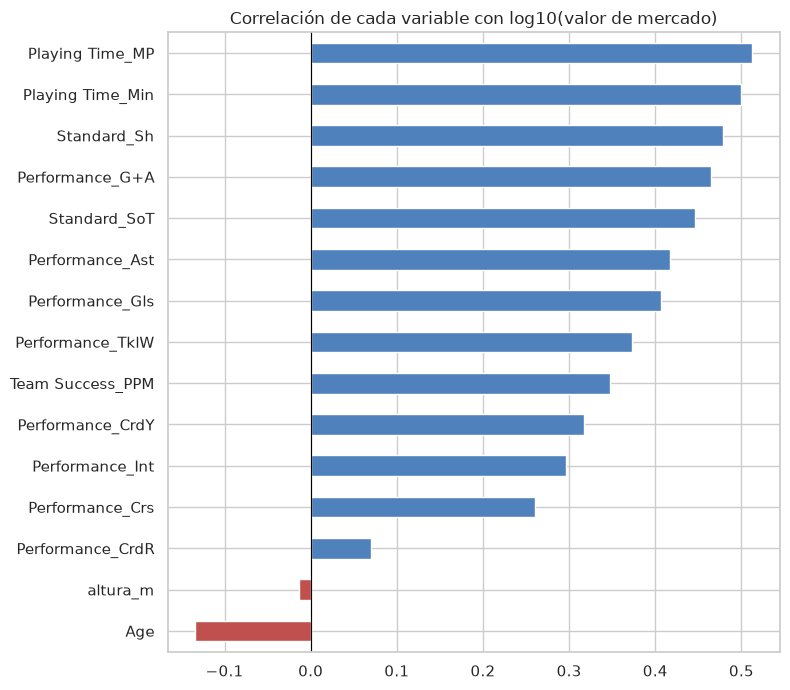

In [36]:
corr_target = corr['log_valor_eur'].drop('log_valor_eur').sort_values()
fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#c0504d' if v < 0 else '#4f81bd' for v in corr_target]
corr_target.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Correlación de cada variable con log10(valor de mercado)')
ax.axvline(0, color='black', lw=.8)
plt.tight_layout()
plt.show()

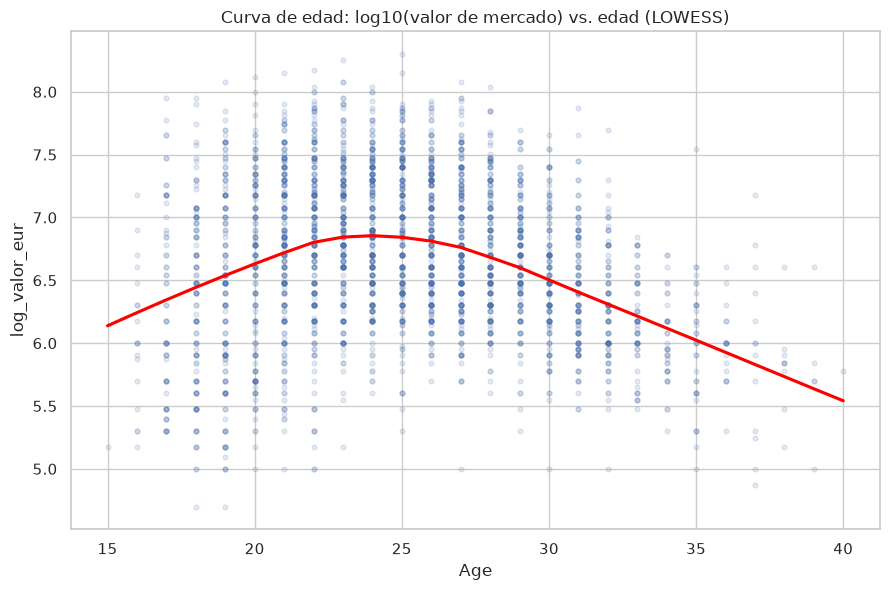

In [37]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.regplot(data=df_model.sample(3000, random_state=RANDOM_STATE), x='Age', y='log_valor_eur',
            lowess=True, scatter_kws={'alpha': .15, 's': 12}, line_kws={'color': 'red'}, ax=ax)
ax.set_title('Curva de edad: log10(valor de mercado) vs. edad (LOWESS)')
plt.tight_layout()
plt.show()

Se observa la clásica **curva de edad** del mercado de fichajes: el valor aumenta con la proyección/juventud, alcanza su punto máximo alrededor de los 23-27 años, y decae de forma sostenida a partir de ahí.

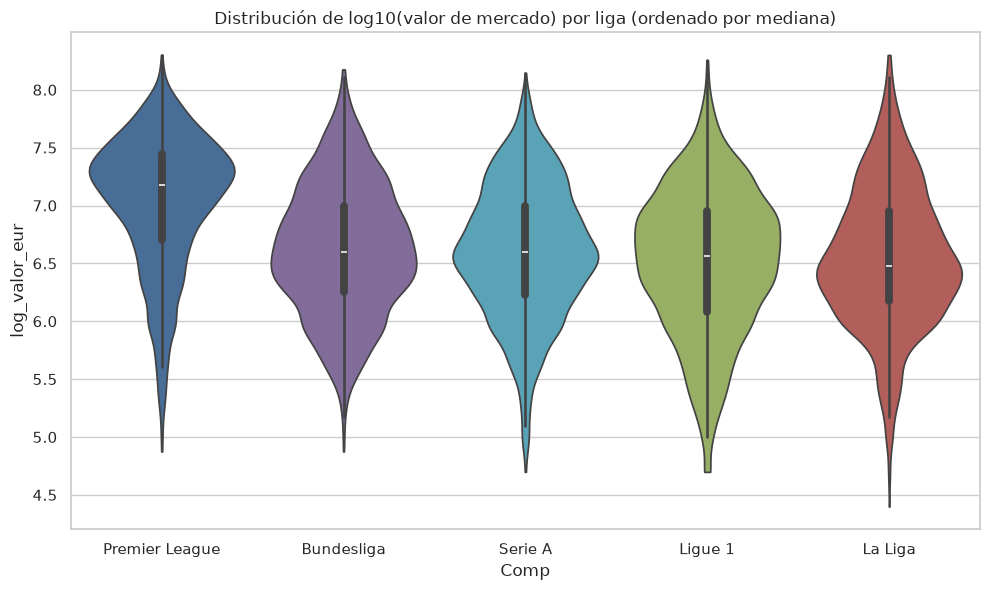

In [38]:
order = df_model.groupby('Comp', observed=True)['log_valor_eur'].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df_model, x='Comp', y='log_valor_eur', order=order,
                palette=[LIGA_COLOR[c] for c in order], ax=ax, cut=0)
ax.set_title('Distribución de log10(valor de mercado) por liga (ordenado por mediana)')
plt.tight_layout()
plt.show()

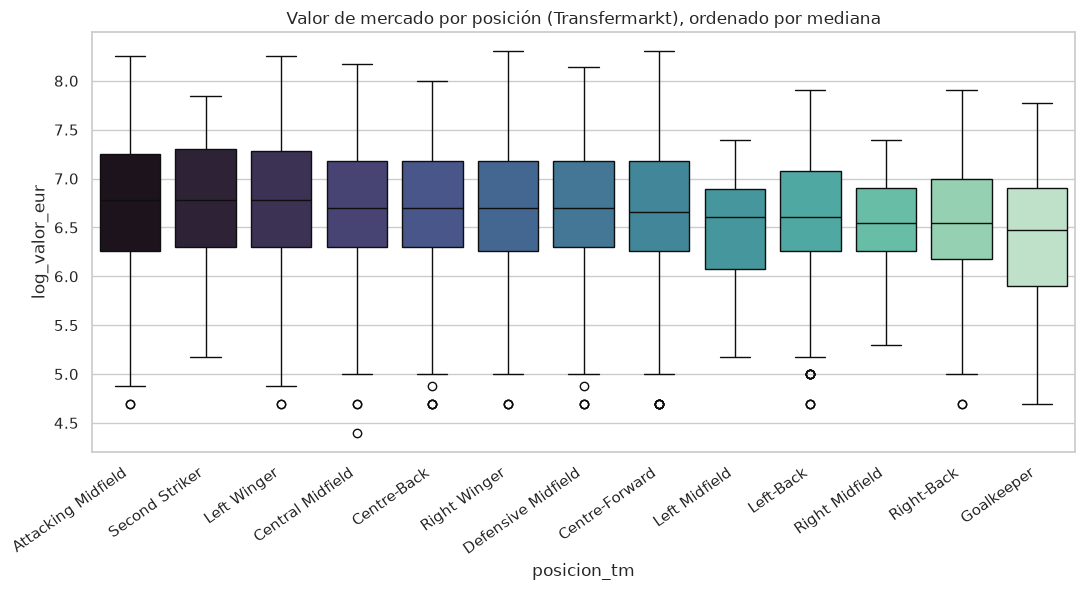

In [39]:
order_pos = df_model.groupby('posicion_tm', observed=True)['log_valor_eur'].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=df_model, x='posicion_tm', y='log_valor_eur', order=order_pos, palette='mako', ax=ax)
ax.set_title('Valor de mercado por posición (Transfermarkt), ordenado por mediana')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

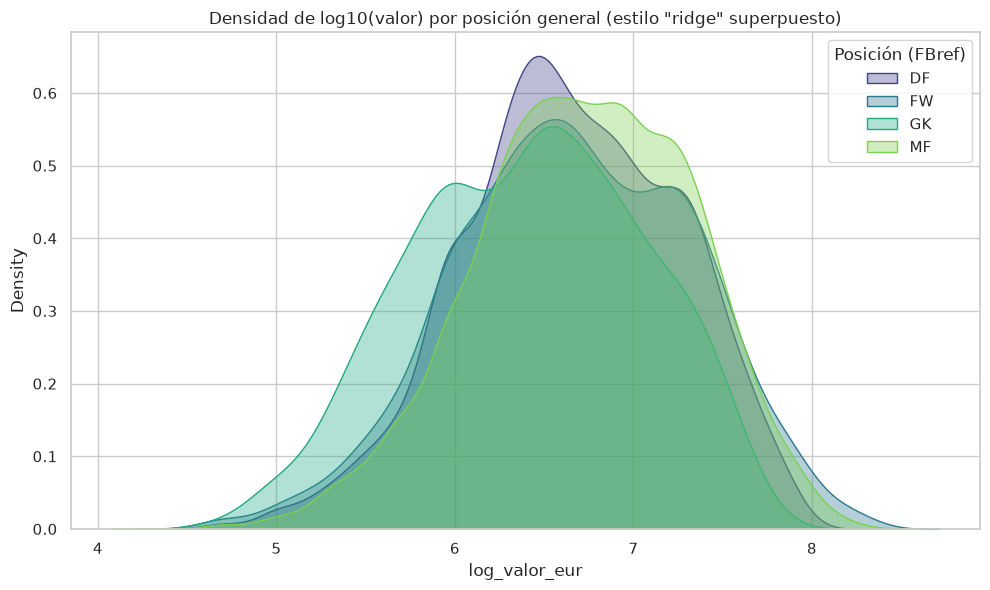

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))
pos_simplificada = df_model['Pos'].astype(str).str.split(',').str[0]
palette = sns.color_palette('viridis', pos_simplificada.nunique())
for color, pos in zip(palette, sorted(pos_simplificada.unique())):
    sns.kdeplot(df_model.loc[pos_simplificada == pos, 'log_valor_eur'], ax=ax, fill=True,
                alpha=.35, label=pos, color=color)
ax.set_title('Densidad de log10(valor) por posición general (estilo "ridge" superpuesto)')
ax.legend(title='Posición (FBref)')
plt.tight_layout()
plt.show()

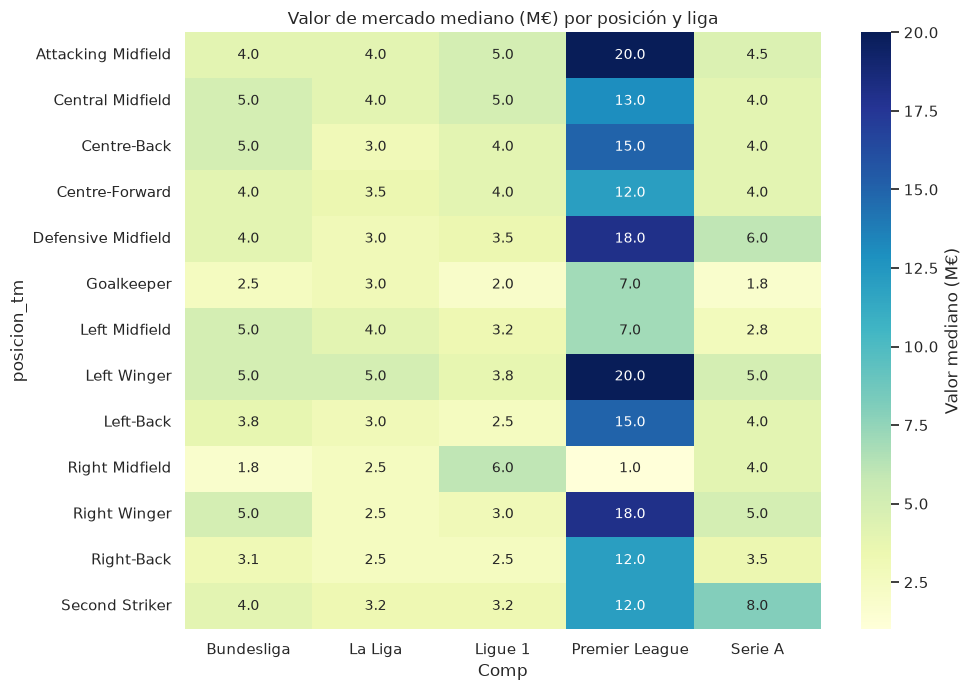

In [41]:
pivot = df_model.pivot_table(index='posicion_tm', columns='Comp', values='valor_eur',
                              aggfunc='median', observed=True) / 1e6
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGnBu', ax=ax, cbar_kws={'label': 'Valor mediano (M€)'})
ax.set_title('Valor de mercado mediano (M€) por posición y liga')
plt.tight_layout()
plt.show()

## 10. Visualizaciones avanzadas / no triviales

In [42]:
fig = px.scatter(df_model.sample(4000, random_state=RANDOM_STATE), x='Age', y='valor_eur', color='Comp',
                  color_discrete_map=LIGA_COLOR, size='Playing Time_Min', size_max=18,
                  hover_name='Player', hover_data={'Squad': True, 'Season': True},
                  log_y=True, opacity=.6,
                  title='Valor de mercado vs. edad (tamaño = minutos jugados, escala log en Y)')
fig.update_layout(height=550)
fig

In [43]:
club_val = df_model.groupby(['Comp', 'club'], observed=True)['valor_eur'].sum().reset_index()
top_clubs = club_val.sort_values('valor_eur', ascending=False).groupby('Comp', observed=True).head(10)
fig = px.treemap(top_clubs, path=['Comp', 'club'], values='valor_eur', color='valor_eur',
                  color_continuous_scale='Blues',
                  title='Valor de plantilla acumulado — top 10 clubes por liga')
fig.update_layout(height=600)
fig

In [44]:
sun = df_model.groupby(['Comp', 'posicion_tm'], observed=True)['valor_eur'].mean().reset_index()
fig = px.sunburst(sun, path=['Comp', 'posicion_tm'], values='valor_eur', color='valor_eur',
                   color_continuous_scale='RdYlGn',
                   title='Valor medio de mercado — Liga > Posición')
fig.update_layout(height=650)
fig

In [45]:
pc_feats = ['Age', 'Playing Time_Min', 'Performance_Gls', 'Performance_Ast', 'Standard_Sh', 'log_valor_eur']
sample_pc = df_model[pc_feats + ['valor_eur']].sample(1500, random_state=RANDOM_STATE)
fig = px.parallel_coordinates(sample_pc, dimensions=pc_feats, color='valor_eur',
                               color_continuous_scale='Turbo',
                               title='Coordenadas paralelas del perfil de jugador (color = valor de mercado)')
fig.update_layout(height=550)
fig

In [46]:
radar_stats = ['Per 90 Minutes_Gls', 'Per 90 Minutes_Ast', 'Standard_Sh/90',
               'Standard_SoT/90', 'Performance_Crs', 'Performance_TklW']
delanteros = df_model[df_model['posicion_tm'].isin(
    ['Centre-Forward', 'Left Winger', 'Right Winger', 'Second Striker'])]
top5 = delanteros.sort_values('valor_eur', ascending=False).drop_duplicates('player_id').head(5)

norm = (delanteros[radar_stats] - delanteros[radar_stats].min()) / (delanteros[radar_stats].max() - delanteros[radar_stats].min())
norm_top5 = norm.loc[top5.index]

fig = go.Figure()
for idx, row in norm_top5.iterrows():
    fig.add_trace(go.Scatterpolar(
        r=row.values.tolist() + [row.values[0]],
        theta=radar_stats + [radar_stats[0]],
        name=f"{top5.loc[idx, 'Player']} ({top5.loc[idx, 'Season']})",
        fill='toself', opacity=.6))
fig.update_layout(title='Perfil comparativo (normalizado 0-1) — Top 5 delanteros más valorados',
                   polar=dict(radialaxis=dict(visible=True, range=[0, 1])), height=600)
fig

### Red de correlación entre variables

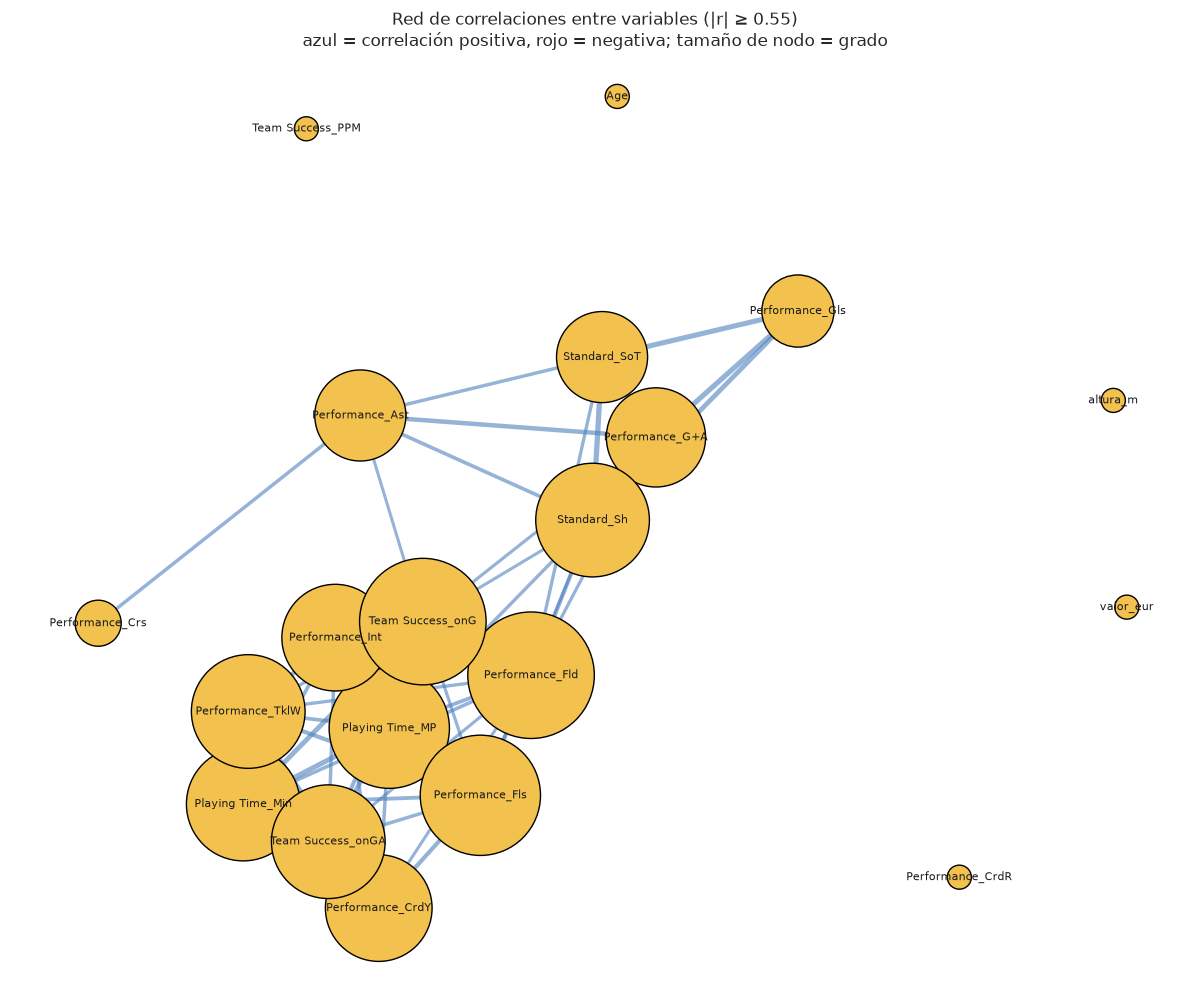

In [47]:
net_feats = ['Age', 'altura_m', 'Playing Time_Min', 'Playing Time_MP', 'Performance_Gls',
             'Performance_Ast', 'Performance_G+A', 'Standard_Sh', 'Standard_SoT',
             'Performance_CrdY', 'Performance_CrdR', 'Performance_Crs', 'Performance_Int',
             'Performance_TklW', 'Performance_Fls', 'Performance_Fld', 'Team Success_PPM',
             'Team Success_onG', 'Team Success_onGA', 'valor_eur']
C = df_model[net_feats].corr()

G = nx.Graph()
G.add_nodes_from(net_feats)
thr = 0.55
for i, a in enumerate(net_feats):
    for b in net_feats[i + 1:]:
        w = C.loc[a, b]
        if abs(w) >= thr:
            G.add_edge(a, b, weight=w)

pos = nx.spring_layout(G, seed=RANDOM_STATE, k=0.9)
edge_colors = ['#c0504d' if G[a][b]['weight'] < 0 else '#4f81bd' for a, b in G.edges()]
edge_widths = [abs(G[a][b]['weight']) * 4 for a, b in G.edges()]
deg = dict(G.degree())
node_sizes = [300 + 800 * deg[n] for n in G.nodes()]

fig, ax = plt.subplots(figsize=(12, 10))
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths, alpha=.6, ax=ax)
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='#f2c14e', edgecolors='black', ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
ax.set_title(f'Red de correlaciones entre variables (|r| ≥ {thr})\n'
             'azul = correlación positiva, rojo = negativa; tamaño de nodo = grado')
ax.axis('off')
plt.tight_layout()
plt.show()

La red revela **clusters de multicolinealidad**: un grupo de variables ofensivas (goles, tiros, tiros a puerta, asistencias) muy interconectado, y otro de variables defensivas/de participación (minutos, partidos, faltas). Para el modelado esto sugiere aplicar selección de variables, regularización (Ridge/Lasso) o reducción de dimensionalidad en vez de introducir todas las métricas crudas.

### Red de traspasos entre clubes

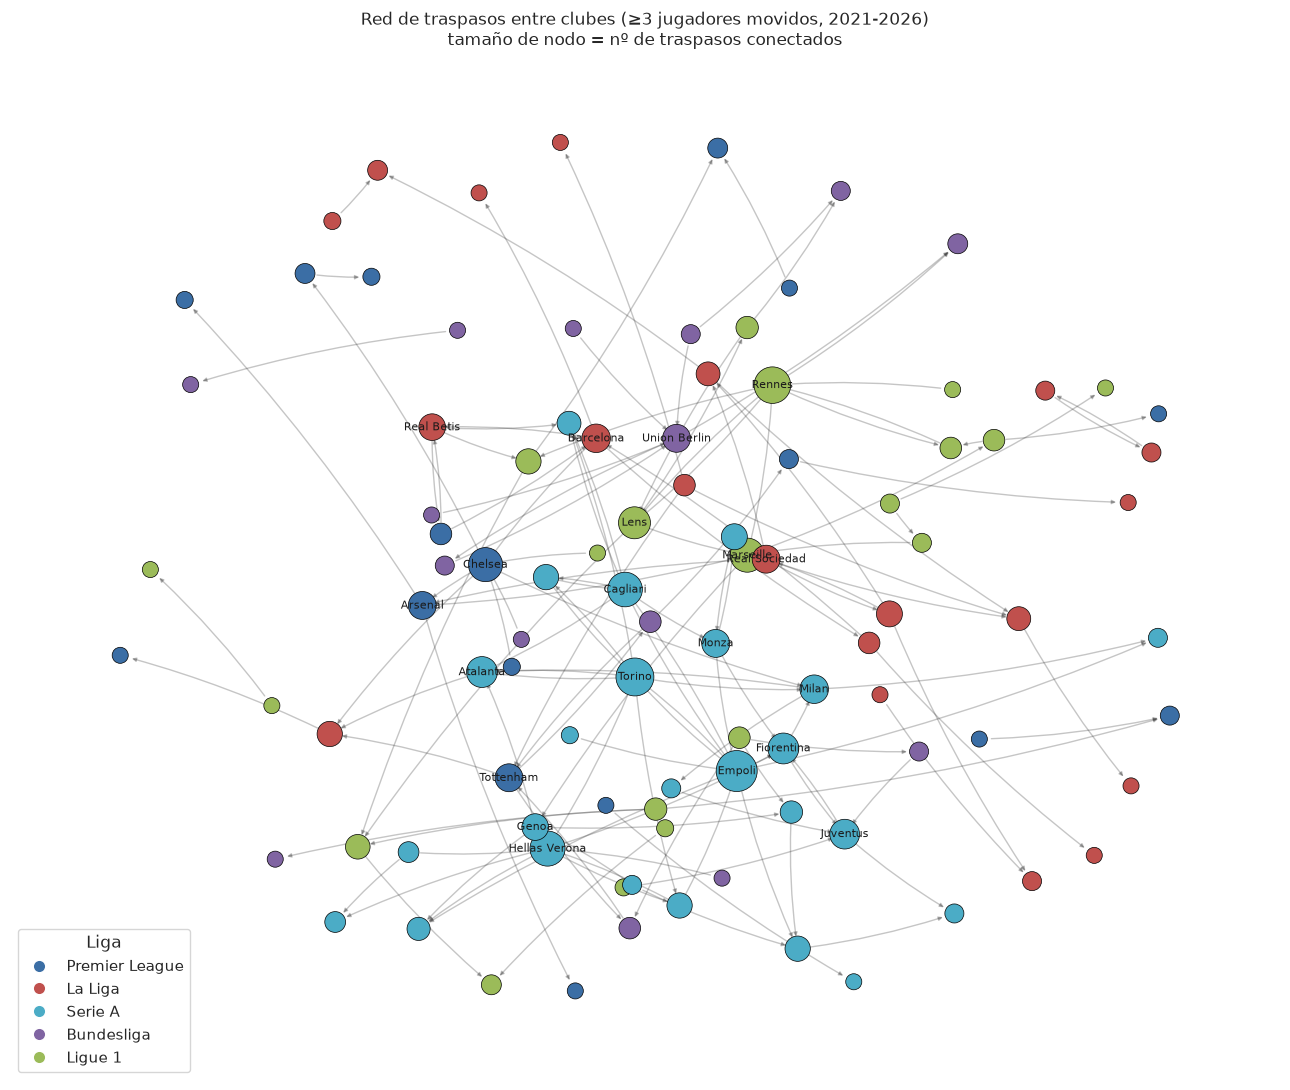

In [48]:
d = df_model[['player_id', 'Season', 'Squad', 'Comp']].sort_values(['player_id', 'Season'])
edges = []
for pid, g in d.groupby('player_id', sort=False, observed=True):
    squads = g['Squad'].tolist()
    for a, b in zip(squads[:-1], squads[1:]):
        if a != b:
            edges.append((a, b))

ew = pd.Series(edges).value_counts()
ew = ew[ew >= 3]

Gc = nx.DiGraph()
for (a, b), w in ew.items():
    Gc.add_edge(a, b, weight=w)

club_liga = df_model.groupby('Squad', observed=True)['Comp'].agg(lambda x: x.value_counts().idxmax())
node_colors = [LIGA_COLOR.get(club_liga.get(n, ''), 'gray') for n in Gc.nodes()]
deg_w = dict(Gc.degree(weight='weight'))
node_sizes = [80 + 18 * deg_w[n] for n in Gc.nodes()]

pos = nx.spring_layout(Gc, seed=RANDOM_STATE, k=0.5)
fig, ax = plt.subplots(figsize=(13, 11))
nx.draw_networkx_edges(Gc, pos, alpha=.25, arrowsize=6, ax=ax, connectionstyle='arc3,rad=0.05')
nx.draw_networkx_nodes(Gc, pos, node_size=node_sizes, node_color=node_colors, edgecolors='black', linewidths=.5, ax=ax)
top_hubs = sorted(deg_w, key=deg_w.get, reverse=True)[:20]
hub_labels = {n: n for n in top_hubs}
nx.draw_networkx_labels(Gc, pos, labels=hub_labels, font_size=8, ax=ax)
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=9, label=l)
           for l, c in LIGA_COLOR.items()]
ax.legend(handles=handles, loc='lower left', title='Liga')
ax.set_title('Red de traspasos entre clubes (≥3 jugadores movidos, 2021-2026)\n'
             'tamaño de nodo = nº de traspasos conectados')
ax.axis('off')
plt.tight_layout()
plt.show()

### Mapa geográfico de origen de los jugadores

In [49]:
iso3_map = {
    'ESP': 'ESP', 'FRA': 'FRA', 'GER': 'DEU', 'ITA': 'ITA', 'ENG': 'GBR', 'BRA': 'BRA', 'ARG': 'ARG',
    'NED': 'NLD', 'POR': 'PRT', 'BEL': 'BEL', 'SEN': 'SEN', 'MAR': 'MAR', 'DEN': 'DNK', 'CIV': 'CIV',
    'SUI': 'CHE', 'AUT': 'AUT', 'CRO': 'HRV', 'SRB': 'SRB', 'NGA': 'NGA', 'POL': 'POL', 'SWE': 'SWE',
    'ALG': 'DZA', 'GHA': 'GHA', 'USA': 'USA', 'CMR': 'CMR', 'NOR': 'NOR', 'URU': 'URY', 'MLI': 'MLI',
    'COL': 'COL', 'SCO': 'GBR', 'JPN': 'JPN', 'TUR': 'TUR', 'IRL': 'IRL', 'CZE': 'CZE', 'WAL': 'GBR',
    'ALB': 'ALB', 'COD': 'COD', 'GUI': 'GIN', 'GRE': 'GRC', 'UKR': 'UKR', 'SVK': 'SVK', 'BIH': 'BIH',
    'ROU': 'ROU', 'KVX': 'XKX', 'TUN': 'TUN', 'HUN': 'HUN', 'CHI': 'CHL', 'SVN': 'SVN', 'KOR': 'KOR',
    'JAM': 'JAM', 'MEX': 'MEX', 'ECU': 'ECU', 'CAN': 'CAN', 'BFA': 'BFA', 'ANG': 'AGO', 'VEN': 'VEN',
    'FIN': 'FIN', 'GEO': 'GEO', 'PAR': 'PRY', 'GAB': 'GAB', 'EGY': 'EGY', 'AUS': 'AUS', 'MNE': 'MNE',
    'HAI': 'HTI', 'GNB': 'GNB', 'NIR': 'GBR', 'RUS': 'RUS', 'ZIM': 'ZWE', 'MKD': 'MKD', 'GAM': 'GMB',
    'COM': 'COM', 'SUR': 'SUR', 'ISR': 'ISR', 'DOM': 'DOM', 'LUX': 'LUX', 'CPV': 'CPV', 'GLP': None,
    'EQG': 'GNQ', 'TOG': 'TGO', 'ZAM': 'ZMB', 'MTQ': None, 'MAD': 'MDG', 'CTA': 'CAF', 'PER': 'PER',
    'ARM': 'ARM', 'NZL': 'NZL', 'BEN': 'BEN', 'CGO': 'COG', 'ISL': 'ISL', 'IDN': 'IDN', 'CRC': 'CRI',
    'MTN': 'MRT', 'BUL': 'BGR', 'UZB': 'UZB', 'GUF': None, 'MLT': 'MLT', 'MOZ': 'MOZ', 'IRN': 'IRN',
    'HON': 'HND', 'CYP': 'CYP', 'RSA': 'ZAF', 'NCL': None, 'PHI': 'PHL', 'LTU': 'LTU', 'BDI': 'BDI',
    'JOR': 'JOR', 'EST': 'EST', 'GRN': 'GRD', 'SLE': 'SLE', 'CUW': None, 'IRQ': 'IRQ', 'PAN': 'PAN',
    'KEN': 'KEN', 'BAN': 'BGD', 'MDA': 'MDA', 'LVA': 'LVA', 'KSA': 'SAU', 'MAS': 'MYS', 'NIG': 'NER',
    'UGA': 'UGA', 'PLE': 'PSE', 'CHN': 'CHN', 'CHA': 'TCD', 'SYR': 'SYR', 'PUR': None, 'UAE': 'ARE',
    'MSR': None, 'TRI': 'TTO', 'FRO': None, 'LBY': 'LBY', 'THA': 'THA', 'BRB': 'BRB', 'TAN': 'TZA',
    'Desconocida': None,
}
nation_stats = df_model.groupby('Nation', observed=True).agg(
    n_jugadores=('Player', 'count'), valor_medio=('valor_eur', 'mean')).reset_index()
nation_stats['iso3'] = nation_stats['Nation'].map(iso3_map)
cobertura = nation_stats.loc[nation_stats['iso3'].notna(), 'n_jugadores'].sum() / nation_stats['n_jugadores'].sum()
print(f"Cobertura del mapeo a código ISO-3: {cobertura*100:.1f}% de las filas "
      f"(Inglaterra/Escocia/Gales/Irlanda del N. se agrupan en GBR; micro-territorios sin código quedan fuera)")
nation_stats = nation_stats.dropna(subset=['iso3'])

fig = px.choropleth(nation_stats, locations='iso3', color='n_jugadores', hover_name='Nation',
                     color_continuous_scale='Viridis',
                     title='Nº de jugadores por nacionalidad en las 5 grandes ligas (2021-2026)')
fig.update_layout(height=500)
fig

Cobertura del mapeo a código ISO-3: 99.6% de las filas (Inglaterra/Escocia/Gales/Irlanda del N. se agrupan en GBR; micro-territorios sin código quedan fuera)


In [50]:
fig = px.choropleth(nation_stats, locations='iso3', color='valor_medio', hover_name='Nation',
                     color_continuous_scale='RdYlGn',
                     title='Valor de mercado medio (€) por nacionalidad')
fig.update_layout(height=500)
fig

### Proyección global de perfiles de jugador (PCA)

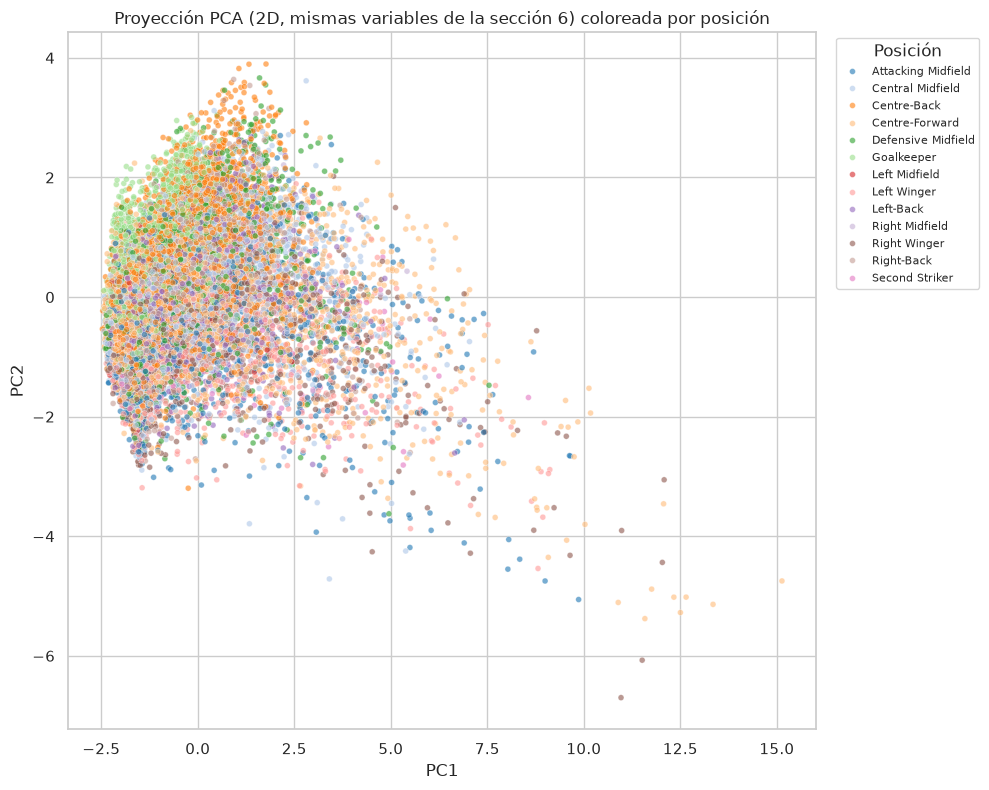

In [51]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(x=df_pca['PC1'], y=df_pca['PC2'], hue=df_model['posicion_tm'].values,
                 palette='tab20', s=18, alpha=.6, ax=ax)
ax.set_title('Proyección PCA (2D, mismas variables de la sección 6) coloreada por posición')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, title='Posición')
plt.tight_layout()
plt.show()

## 11. Ranking final y guardado del dataset tratado

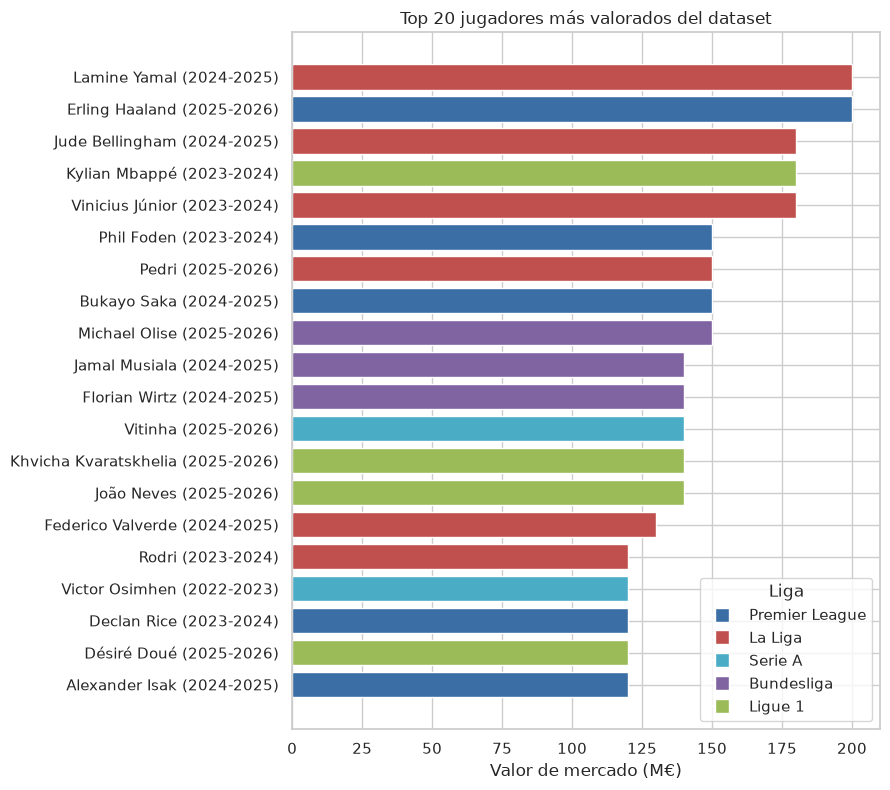

In [52]:
top20 = df_model.sort_values('valor_eur', ascending=False).drop_duplicates('player_id').head(20)
fig, ax = plt.subplots(figsize=(9, 8))
colors = [LIGA_COLOR.get(c, 'gray') for c in top20['Comp']]
ax.barh(top20['Player'] + ' (' + top20['Season'].astype(str) + ')', top20['valor_eur'] / 1e6, color=colors)
ax.invert_yaxis()
ax.set_xlabel('Valor de mercado (M€)')
ax.set_title('Top 20 jugadores más valorados del dataset')
handles = [plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=c, markersize=10, label=l)
           for l, c in LIGA_COLOR.items()]
ax.legend(handles=handles, loc='lower right', title='Liga')
plt.tight_layout()
plt.show()

In [53]:
export_path = OUT_DIR / 'fbref_tm_eda.parquet'
df_model.to_parquet(export_path, index=False)
print('Dataset tratado exportado a:', export_path.resolve())
print('Shape final:', df_model.shape)

Dataset tratado exportado a: /home/diego/Documentos/Diplomado Ciencia de Datos/Modulo_5/Proyecto/fut-analisis/data/processed/fbref_tm_eda.parquet
Shape final: (13835, 90)


## 12. Conclusiones

**Calidad de datos**
- Se corrigió un tipo de dato mal inferido (`Per 90 Minutes_G-PK` venía como texto) y se tipificaron correctamente fechas y categóricas.
- 639 jugadores (1,473 filas) comparten jugador+temporada por traspasos a mitad de temporada: son legítimas, pero **duplican el valor objetivo** entre las filas de un mismo jugador → dividir cualquier train/test **por `player_id`**, nunca por fila, para evitar fuga de información.
- El campo `club` de Transfermarkt es una instantánea, no un histórico por temporada; en temporadas antiguas puede no coincidir con el `Squad` real de esa temporada, lo que introduce ruido leve en `valor_eur` para años lejanos al scraping.
- Las taxonomías de posición de FBref y Transfermarkt son coherentes entre sí, por lo que `posicion_tm` puede usarse con confianza como variable categórica de posición.

**Valores faltantes**
- Todos los faltantes explicados con causas estructurales (ratios de tiro sin tiros, minutos sin titularidades/suplencias) y tratados con imputación 0 + flags indicadoras.
- Métricas de éxito de equipo y altura imputadas con medianas por grupo (liga-temporada y posición, respectivamente).
- Los campos de auditoría del cruce (`anio_nac`, `pid_fb`) se dejaron sin imputar y no deben usarse como *features* de modelado.
- El 0.8% de filas sin `valor_eur` corresponde a jugadores muy jóvenes con pocos minutos (aún sin valoración pública) y se excluyó del subconjunto de trabajo (`df_model`).

**Atípicos**
- Los métodos univariantes (IQR, Z-score, Z-score modificado) y multivariantes (Isolation Forest, LOF, Elliptic Envelope, Mahalanobis) coinciden en señalar como atípicos a los futbolistas de mayor rendimiento y valor de mercado (Messi, Mbappé, Haaland, Lamine Yamal…).
- **No se eliminó ninguna observación**: son la señal más valiosa para el problema de negocio. En su lugar se aplicó log-transformación al objetivo y a variables de conteo muy asimétricas, y se usará escalado robusto (`RobustScaler`) de cara al modelado.

**Relación con el objetivo**
- `log10(valor_eur)` sigue la curva de edad esperada (pico ~23-27 años) y correlaciona positivamente con minutos jugados, goles y asistencias.
- La Premier League y La Liga muestran las medianas de valor más altas; delanteros y extremos superan sistemáticamente a defensas centrales y porteros.
- La red de correlación entre variables evidencia clusters de multicolinealidad (ofensivas vs. defensivas/de participación) a tener en cuenta para la selección de variables o regularización en el modelo.

**Dataset resultante:** `data/processed/fbref_tm_eda.parquet` — listo para ingeniería de variables y modelado, con flags de calidad de datos incorporados.